# A Deep Reinforcement Learning Framework for Multi-Year Sustainable Crop Planning under Uncertainty

Pooja Balakumar A00029779 MSc Data Science



In [ ]:
# CELL 1
# Install required packages
!pip install gymnasium stable-baselines3 shimmy pandas numpy matplotlib openpyxl lxml html5lib

import os # STEP 1: Import operating system utilities. Os is used for handling file paths and checking files/folders.
import random  # STEP 2: Import random number utilities. Random is used when random choices or random sampling are needed in the simulation.
import collections # STEP 3: Import collections module. Collections provides specialised data structures such as defaultdict or deque.
import numpy as np # STEP 4: Import NumPy. NumPy is used for numerical calculations, arrays, and random numerical operations.
import pandas as pd # STEP 5: Import Pandas. Pandas is used for loading, cleaning, and processing crop dataset tables.
import matplotlib.pyplot as plt # STEP 6: Import Matplotlib. Matplotlib is used to create graphs and visualisations for results.

# STEP 7: Try importing PyTorch
# PyTorch is used internally by Stable-Baselines3 for deep learning models.
#If PyTorch is not available, torch is set to None to avoid crashing immediately.
try:
    import torch . 
except ImportError:
    torch = None

# STEP 8: Import Gymnasium
# Gymnasium is used to build the custom reinforcement learning environment.
import gymnasium as gym

# STEP 9: Import Gymnasium spaces
# spaces define the observation space and action space of the RL environment
from gymnasium import spaces

# STEP 10: Import RL algorithms
# PPO is used for continuous/proportional land allocation.
# DQN is used for discrete action-template based learning.
from stable_baselines3 import PPO, DQN

# STEP 11: Import Monitor wrapper
# Monitor records training statistics such as episode rewards and episode lengths.
from stable_baselines3.common.monitor import Monitor


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 33.6 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 2 
# STEP 1: Set a fixed random seed
# This makes the experiment reproducible.
# Using the same seed helps produce the same random numbers each time the notebook is run.
SEED = 42

# STEP 2: Set Python's built-in random seed
# This controls randomness from the random module.
random.seed(SEED)

# STEP 3: Set NumPy random seed
# This controls randomness used in NumPy operations.
np.random.seed(SEED)

# STEP 4: Set PyTorch random seed if PyTorch is available
# Stable-Baselines3 uses PyTorch internally, so this helps make RL training more reproducible.
if torch is not None:
    torch.manual_seed(SEED)

    # STEP 5: Set CUDA random seed if GPU is available
    # This controls randomness when training is performed on GPU.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

# STEP 6: Create output folders
# These folders are used to store result files, tables, and generated figures.
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

# STEP 7: Define dataset path
# The dataset file is supplied for this project.
# Although it has a .xls extension, it is actually stored as an HTML table.
DATA_PATH = "horizontal_crop_vertical_year_report_2003_23.xls"

# STEP 8: Check whether the dataset exists
# If the file is not found, the code checks an alternative path with the same filename.
if not os.path.exists(DATA_PATH):
    alt_path = "horizontal_crop_vertical_year_report_2003_23.xls"
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

# STEP 9: Define total available land
# The farmer has 100 decares of land available for crop planning.
TOTAL_LAND_DECARE = 100

# STEP 10: Define initial savings
# This is the farmer's starting financial balance at the beginning of the simulation.
INITIAL_SAVINGS = 20_000.0

# STEP 11: Define normal annual living cost
# This represents the farmer's household cost per year.
NORMAL_LIVING_COST = 10_000.0

# STEP 12: Define living cost variation
# Living cost varies by ±10% to represent inflation and unexpected household expenses.
LIVING_COST_VARIATION = 0.10

# STEP 13: Define planning horizon
# The crop planning simulation runs for 20 years.
HORIZON_YEARS = 20

# STEP 14: Define tree maturity period
# Tree/perennial crops require 3 years before they start generating revenue.
TREE_MATURITY_YEARS = 3

# STEP 15: Define minimum crop area
# If a crop is selected, it should be assigned at least 5 decares for practical efficiency.
MIN_AREA_DECARE = 5

# STEP 16: Define reinforcement learning training scale
# The supervisor requested 200,000 training steps for the final experiment.
# Smaller values may be used only for quick testing.
TRAINING_STEPS = 200_000

# STEP 17: Define number of testing episodes
# The trained models are evaluated over 1,000 independent simulation runs.
TEST_EPISODES = 1_000

# STEP 18: Define probability of cold weather
# Cold weather occurs with 40% probability in each simulated year.
COLD_PROBABILITY = 0.40

# STEP 19: Define probability of low rainfall
# Low rainfall occurs with 40% probability in each simulated year.
LOW_RAIN_PROBABILITY = 0.40

# STEP 20: Define general productivity variation
# Crop productivity can vary by ±10% due to normal agricultural uncertainty.
GENERAL_PRODUCTIVITY_VARIATION = 0.10

# STEP 21: Define reward scaling factor
# Scaling keeps reward values numerically stable for RL algorithms such as PPO and DQN.
# Raw reward logic is preserved, but values are divided by this factor
REWARD_SCALE = 10_000.0


In [ ]:
# CELL 3
# Dataset loading and crop-parameter calibration
# STEP 1: Load the uploaded agricultural dataset
# The dataset has an .xls extension, but it is actually stored as an HTML table.
# Therefore, pd.read_html() is used instead of pd.read_excel().
try:
    crop_tables = pd.read_html(DATA_PATH)

    # STEP 2: Select the first table from the loaded HTML tables
    # The required crop data is stored in the first table
    crop_dataset = crop_tables[0]

    # STEP 3: Print confirmation that the dataset has been loaded successfully
    print(f"Loaded dataset from: {DATA_PATH}")
    print(f"Dataset shape: {crop_dataset.shape[0]} rows x {crop_dataset.shape[1]} columns")

# STEP 4: If dataset loading fails, use fallback values later
# This prevents the notebook from stopping completely if the file cannot be read.
except Exception as exc:
    crop_dataset = None
    print("WARNING: Could not load the uploaded dataset. The notebook will use fallback productivity values.")
    print("Reason:", exc)

# STEP 5: Define annual crops used in the simulation
# Annual crops generate yield and revenue within the same year.
ANNUAL_CROPS = ["wheat", "potato", "onion", "tomato", "barley"]

# STEP 6: Define tree/perennial crops used in the simulation
# These crops require a maturity period before producing revenue.
TREE_CROPS = ["mango", "banana", "cashewnut", "citrus_fruit", "pome_fruit"]

# STEP 7: Combine all crop options into one list
# This list is used throughout the simulation environment.
ALL_CROPS = ANNUAL_CROPS + TREE_CROPS

# Exact dataset column names for each internal crop name.
# STEP 8: Map internal crop names to exact dataset column names
# Internal names are simple Python-friendly names.
# Dataset names match the crop labels found in the uploaded dataset.
DATASET_CROP_NAME = {
    "wheat": "Wheat",
    "potato": "Potato",
    "onion": "Onion",
    "tomato": "Tomato",
    "barley": "Barley",
    "mango": "Mango",
    "banana": "Banana",
    "cashewnut": "Cashewnut",
    "citrus_fruit": "Citrus Fruit",
    "pome_fruit": "Pome Fruit",
}

# STEP 9: Define display labels for crops
# These labels are used in tables and graphs for readability.
CROP_LABELS = {
    "wheat": "Wheat",
    "potato": "Potato",
    "onion": "Onion",
    "tomato": "Tomato",
    "barley": "Barley",
    "mango": "Mango",
    "banana": "Banana",
    "cashewnut": "Cashewnut",
    "citrus_fruit": "Citrus Fruit",
    "pome_fruit": "Pome Fruit",
}

# STEP 10: Define fallback yield values
# These are used if the dataset cannot provide enough usable yield values.
# Unit: kg per decare.
# Conversion rule: 1 tonne/hectare = 100 kg/decare.
FALLBACK_YIELD_KG_PER_DECARE = {
    "wheat": 187.0,
    "potato": 955.0,
    "onion": 880.0,
    "tomato": 755.0,
    "barley": 158.0,
    "mango": 370.0,
    "banana": 2330.0,
    "cashewnut": 42.0,
    "citrus_fruit": 480.0,
    "pome_fruit": 702.0,
}

# STEP 11: Define approximate market prices
# The uploaded dataset contains yield/production/area values but not price data.
# Therefore, prices are manually set as model parameters.
# Unit: GBP per kg
PRICE_PER_KG = {
    # Supervisor guidance: realistic crop price is generally around £1.5-£5 per kg.
    # Lower-yield and riskier crops are assigned higher prices.
    "wheat": 1.50,
    "potato": 1.80,
    "onion": 2.50,
    "tomato": 3.50,
    "barley": 1.50,
    "mango": 2.50,
    "banana": 1.50,
    "cashewnut": 5.00,
    "citrus_fruit": 2.50,
    "pome_fruit": 3.00,
}

# STEP 12: Define cultivation cost ratios
# Cost is estimated as a proportion of expected revenue.
# This follows the supervisor guidance that cultivation cost is roughly one-half or one-third of revenue
COST_RATIO = {
    # Supervisor guidance: cultivation cost is approximately one-half or one-third of revenue.
    "wheat": 0.50,
    "potato": 0.45,
    "onion": 0.45,
    "tomato": 0.50,
    "barley": 0.50,
    "mango": 0.40,
    "banana": 0.45,
    "cashewnut": 0.45,
    "citrus_fruit": 0.40,
    "pome_fruit": 0.45,
}

# STEP 13: Define crop sensitivity to weather shocks
# This follows the supervisor's requested setup:
# - Some crops are cold-sensitive
# - Some crops are rain-sensitive
# - Some crops are sensitive to both
# - Some crops have no special weather limitation
CROP_SENSITIVITY = {
    "wheat": "none",
    "potato": "rain",
    "onion": "both",
    "tomato": "cold",
    "barley": "none",
    "mango": "cold",
    "banana": "rain",
    "cashewnut": "none",
    "citrus_fruit": "none",
    "pome_fruit": "both",
}

# STEP 14: Define a function to extract crop yield from the dataset
# The function returns:
# - yield value in kg per decare
# - number of usable yield records
# - source label explaining whether dataset or fallback was used
def get_dataset_yield_kg_per_decare(internal_crop_name):
    """Return robust median yield from the uploaded dataset in kg/decare."""

    # STEP 15: Get fallback value first
    # This is used if dataset extraction fails.
    fallback = FALLBACK_YIELD_KG_PER_DECARE[internal_crop_name]

# STEP 16: If dataset was not loaded, return fallback value
    if crop_dataset is None:
        return fallback, 0, "fallback_dataset_not_loaded"

# STEP 17: Find the exact crop name in the dataset
    dataset_name = DATASET_CROP_NAME[internal_crop_name]

    
# STEP 18: Define the expected multi-index column for yield
    # The dataset stores yield under crop name, season, and variable type.
    col = (dataset_name, "Whole Year", "Yield (Tonne/Hectare)")

    # STEP 19: If the expected column is missing, return fallback value
    if col not in crop_dataset.columns:
        return fallback, 0, "fallback_column_missing"


    # STEP 20: Convert yield values to numeric form
    # Invalid text values are converted to NaN.
    values = pd.to_numeric(crop_dataset[col], errors="coerce")

    # STEP 21: Keep only finite values
    # This removes NaN and infinite values
    values = values[np.isfinite(values)]

    # STEP 22: Keep only positive yield values
    # Zero or negative yields are not useful for calibration
    values = values[values > 0]

     # STEP 23: Remove extreme outliers if enough records are available
    # Government datasets may contain unusual or erroneous entries.
    # The 99th percentile cap makes the median more robust
    if len(values) >= 20:
        upper_cap = values.quantile(0.99)
        values = values[values <= upper_cap]

# STEP 24: If fewer than 5 usable records remain, use fallback value
    if len(values) < 5:
        return fallback, int(len(values)), "fallback_too_few_values"

# STEP 25: Calculate median yield in tonne/hectare
    # The median is used because it is less affected by outliers than the mean
    median_tonne_per_hectare = float(values.median())

    # STEP 26: Convert tonne/hectare to kg/decare
    # 1 tonne/hectare = 100 kg/decare.
    kg_per_decare = median_tonne_per_hectare * 100.0

     # STEP 27: Return calibrated yield and metadata
    return kg_per_decare, int(len(values)), "dataset_median"


# STEP 28: Create empty containers for final crop configuration and calibration table
CROP_CONFIG = {}
calibration_rows = []

# STEP 29: Loop through every crop and build the final parameter configuration
for crop in ALL_CROPS:

    # STEP 30: Get dataset-calibrated yield or fallback yield
    yield_kg_decare, usable_n, source = get_dataset_yield_kg_per_decare(crop)

# STEP 31: Store crop parameters in CROP_CONFIG
    # This dictionary is later used inside the Virtual Farm environment.
    CROP_CONFIG[crop] = {
        "price_per_kg": PRICE_PER_KG[crop],
        "yield_kg_per_decare": yield_kg_decare,
        "cost_ratio": COST_RATIO[crop],
        "sensitivity": CROP_SENSITIVITY[crop],
        "dataset_crop": DATASET_CROP_NAME[crop],
        "yield_source": source,
        "usable_yield_records": usable_n,
    }


    # STEP 32: Calculate expected revenue per decare
    # Expected revenue = price per kg × expected yield per decare.
    expected_revenue = PRICE_PER_KG[crop] * yield_kg_decare

    # STEP 33: Calculate expected cultivation cost per decare
    # Expected cost = expected revenue × cost ratio.
    expected_cost = expected_revenue * COST_RATIO[crop]

# STEP 34: Add crop information to calibration table
    # This table is useful for reporting and checking assumptions.
    calibration_rows.append({
        "Crop/Tree": CROP_LABELS[crop],
        "Type": "Annual" if crop in ANNUAL_CROPS else "Tree/Perennial",
        "Dataset Crop Name": DATASET_CROP_NAME[crop],
        "Usable Yield Records": usable_n,
        "Yield Source": source,
        "Yield kg per decare": yield_kg_decare,
        "Price per kg (£)": PRICE_PER_KG[crop],
        "Expected revenue per decare (£)": expected_revenue,
        "Cost ratio": COST_RATIO[crop],
        "Expected cost per decare (£)": expected_cost,
        "Sensitivity": CROP_SENSITIVITY[crop],
    })

# STEP 35: Convert calibration rows into a Pandas DataFrame
# This creates a clean table of all crop parameters
crop_parameter_table = pd.DataFrame(calibration_rows)

# STEP 36: Display the final calibrated crop parameter table
print("Dataset-calibrated crop parameter table")
display(crop_parameter_table)

# STEP 37: Save the parameter table as a CSV file
# This allows the calibration table to be reused in the report or appendix.
crop_parameter_table.to_csv("outputs/dataset_calibrated_crop_parameters.csv", index=False)


Loaded dataset from: horizontal_crop_vertical_year_report_2003_23.xls
Dataset shape: 9447 rows x 291 columns
Dataset-calibrated crop parameter table


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Type,Dataset Crop Name,Usable Yield Records,Yield Source,Yield kg per decare,Price per kg (£),Expected revenue per decare (£),Cost ratio,Expected cost per decare (£),Sensitivity
0,Wheat,Annual,Wheat,66,dataset_median,187.0,1.5,280.50,0.50,140.2500,none
1,Potato,Annual,Potato,3758,dataset_median,944.0,1.8,1699.20,0.45,764.6400,rain
2,Onion,Annual,Onion,3754,dataset_median,873.0,2.5,2182.50,0.45,982.1250,both
3,Tomato,Annual,Tomato,112,dataset_median,730.5,3.5,2556.75,0.50,1278.3750,cold
4,Barley,Annual,Barley,37,dataset_median,157.0,1.5,235.50,0.50,117.7500,none
5,Mango,Tree/Perennial,Mango,182,dataset_median,364.0,2.5,910.00,0.40,364.0000,cold
6,Banana,Tree/Perennial,Banana,3168,dataset_median,2302.5,1.5,3453.75,0.45,1554.1875,rain
7,Cashewnut,Tree/Perennial,Cashewnut,1287,dataset_median,41.0,5.0,205.00,0.45,92.2500,none
8,Citrus Fruit,Tree/Perennial,Citrus Fruit,89,dataset_median,480.0,2.5,1200.00,0.40,480.0000,none
9,Pome Fruit,Tree/Perennial,Pome Fruit,84,dataset_median,702.0,3.0,2106.00,0.45,947.7000,both


In [ ]:
# CELL 4

# STEP 1: Define a function to generate yearly stochastic crop economics
# This function produces the actual price, yield, and cost for one crop/tree in one simulated year.
def sample_crop_economics(crop_name, cold_happened, low_rain_happened, rng):
    """
    Returns stochastic price, yield, and cost for one crop/tree in one year.

    Only stochastic elements change between generated instances:
    - price multiplier
    - cost multiplier
    - productivity multiplier
    - weather shock impact

    Fixed between instances:
    - crop options
    - land size
    - normal price
    - normal productivity
    - normal cost ratio
    - planning horizon
    """

    # STEP 2: Get the fixed configuration for the selected crop
    # CROP_CONFIG contains price, yield, cost ratio, and weather sensitivity for each crop.
    cfg = CROP_CONFIG[crop_name]

    # STEP 3: Extract the base price for the crop
    # This is the normal expected price per kg before random variation is applied.
    base_price = cfg["price_per_kg"]

    # STEP 4: Extract the base yield for the crop
    # This is the normal expected productivity in kg per decare.
    base_yield = cfg["yield_kg_per_decare"]

    # STEP 5: Extract the cultivation cost ratio
    # This ratio is used to estimate cultivation cost from expected revenue.
    cost_ratio = cfg["cost_ratio"]

    # STEP 6: Extract the crop's weather sensitivity type
    # Possible values are: none, cold, rain, or both.
    sensitivity = cfg["sensitivity"]

    # STEP 7: Apply stochastic price variation
    # The actual crop price varies randomly within ±10% of its base price.
    price = base_price * rng.uniform(0.90, 1.10)

    # STEP 8: Apply general productivity variation
    # Crop yield varies randomly within ±10% to represent normal uncertainty.
    productivity_multiplier = rng.uniform(
        1 - GENERAL_PRODUCTIVITY_VARIATION,
        1 + GENERAL_PRODUCTIVITY_VARIATION
    )

    # STEP 9: Start with no weather damage
    # A multiplier of 1.0 means full normal productivity is preserved.
    weather_multiplier = 1.0

    # STEP 10: Apply cold-weather shock if relevant
    # If cold occurs and the crop is cold-sensitive, yield is reduced sharply.
    # Remaining productivity becomes only 10% to 50% of normal.
    if cold_happened and sensitivity in ["cold", "both"]:
        weather_multiplier *= rng.uniform(0.10, 0.50)

    # STEP 11: Apply low-rainfall shock if relevant
    # If rainfall is insufficient and the crop is rain-sensitive, yield is reduced sharply.
    if low_rain_happened and sensitivity in ["rain", "both"]:
        weather_multiplier *= rng.uniform(0.10, 0.50)

    # STEP 12: Calculate the final realised yield
    # Actual yield = base yield × general productivity variation × weather shock effect.
    yield_kg_per_decare = base_yield * productivity_multiplier * weather_multiplier

    # STEP 13: Calculate expected revenue per decare
    # This uses base values, not stochastic values, to estimate normal cultivation cost.
    expected_revenue_per_decare = base_price * base_yield

    # STEP 14: Calculate base cultivation cost per decare
    # Cost is estimated as a fraction of expected revenue using the crop-specific cost ratio.
    base_cost_per_decare = expected_revenue_per_decare * cost_ratio

    # STEP 15: Apply stochastic cost variation
    # Actual cultivation cost varies randomly within ±10%.
    cost_per_decare = base_cost_per_decare * rng.uniform(0.90, 1.10)

    # STEP 16: Return the realised economic values for this crop/year
    # These values are used by the Virtual Farm environment to calculate revenue and cost.
    return price, yield_kg_per_decare, cost_per_decare

In [ ]:
# CELL 5

# STEP 1: Define the custom Virtual Farm environment
# This environment follows the Gymnasium interface so it can be used by RL algorithms.
class FarmEnv(gym.Env):

    # STEP 2: Define metadata
    # No rendering mode is used because this environment is numerical/simulation-based.
    metadata = {"render_modes": []}

    # STEP 3: Initialise the environment
    def __init__(self):
        super().__init__()

        # STEP 4: Store the total land available to the farmer
        # In this project, the farmer has 100 decares of land.
        self.total_land_decare = TOTAL_LAND_DECARE

        # STEP 5: Define the action space
        # PPO uses a continuous action vector with one value for each crop/tree.
        # Each value represents a land allocation weight or fraction.
        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(len(ALL_CROPS),),
            dtype=np.float32
        )

        # STEP 6: Define the observation space
        # The state includes:
        # - scaled savings
        # - scaled current year
        # - scaled tree ages
        # - scaled tree areas
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(2 + len(TREE_CROPS) + len(TREE_CROPS),),
            dtype=np.float32
        )

    # STEP 7: Reset the environment at the beginning of each episode
    # Each episode represents one 20-year farm planning simulation.
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # STEP 8: Reset farmer savings
        # The farmer starts with the initial savings defined in the project setup.
        self.savings = float(INITIAL_SAVINGS)

        # STEP 9: Reset current year to zero
        self.current_year = 0

        # STEP 10: Reset tree ages
        # At the start, no tree crop has matured.
        self.tree_ages = np.zeros(len(TREE_CROPS), dtype=np.float32)

        # STEP 11: Reset tree areas
        # At the start, no land is allocated to tree crops.
        self.tree_areas = np.zeros(len(TREE_CROPS), dtype=np.float32)

        # STEP 12: Reset counters for environmental events
        self.total_cold_events = 0
        self.total_low_rain_events = 0

        # STEP 13: Reset land allocation history
        # This records crop allocation decisions for later analysis.
        self.area_history = []

        # STEP 14: Track minimum savings seen during the episode
        # This is used to measure financial risk and temporary bankruptcy.
        self.minimum_savings_seen = float(INITIAL_SAVINGS)

        # STEP 15: Return the initial observation and empty info dictionary
        return self._get_obs(), {}

    # STEP 16: Convert the current environment state into an observation vector
    def _get_obs(self):

        # STEP 17: Return scaled observation values
        # Scaling improves numerical stability during RL training.
        return np.array(
            [
                # Scaled current savings
                self.savings / 100_000.0,

                # Scaled current year
                self.current_year / HORIZON_YEARS,

                # Scaled tree ages
                *(self.tree_ages / max(1, TREE_MATURITY_YEARS)),

                # Scaled tree areas
                *(self.tree_areas / self.total_land_decare),
            ],
            dtype=np.float32
        )

    # STEP 18: Convert the raw action vector into real land areas
    def _action_to_areas(self, action):

        # STEP 19: Convert action into NumPy array
        action = np.array(action, dtype=np.float32)

        # STEP 20: Clip action values between 0 and 1
        # This avoids invalid negative or too-large allocations.
        action = np.clip(action, 0.0, 1.0)

        # STEP 21: Interpret the action vector as crop land allocation
        # If action.sum() <= 1, the values are direct fractions of total land.
        # If action.sum() > 1, the values are treated as relative weights and scaled.
        if action.sum() <= 1e-9:

            # STEP 22: If all actions are zero, cultivate no land
            areas = np.zeros(len(ALL_CROPS), dtype=np.float32)

        elif action.sum() <= 1.0:

            # STEP 23: Convert action fractions into decares
            # Example: 0.10 means 10 decares if total land is 100.
            areas = action * self.total_land_decare

        else:

            # STEP 24: If action weights exceed 1, normalise to total land capacity
            areas = action / action.sum() * self.total_land_decare

        # STEP 25: Apply the minimum-area rule
        # If a crop is selected, it must have at least MIN_AREA_DECARE.
        # Smaller allocations are set to zero and become fallow land.
        areas = np.where((areas > 0) & (areas < MIN_AREA_DECARE), 0.0, areas)

        # STEP 26: Ensure total land does not exceed available land
        if areas.sum() > self.total_land_decare:
            areas = areas / areas.sum() * self.total_land_decare

        # STEP 27: Return final land area allocation
        return areas

    # STEP 28: Execute one year of farm simulation
    # The agent selects an action, and the environment returns next state and reward.
    def step(self, action):

        # STEP 29: Convert action into crop areas
        areas = self._action_to_areas(action)

        # STEP 30: Save allocation history
        self.area_history.append(areas.copy())

        # STEP 31: Randomly sample whether cold weather occurs this year
        cold_happened = self.np_random.random() < COLD_PROBABILITY

        # STEP 32: Randomly sample whether low rainfall occurs this year
        low_rain_happened = self.np_random.random() < LOW_RAIN_PROBABILITY

        # STEP 33: Count cold events
        if cold_happened:
            self.total_cold_events += 1

        # STEP 34: Count low-rainfall events
        if low_rain_happened:
            self.total_low_rain_events += 1

        # STEP 35: Generate stochastic living cost
        # Living cost varies around the normal annual value.
        living_cost = NORMAL_LIVING_COST * self.np_random.uniform(
            1 - LIVING_COST_VARIATION,
            1 + LIVING_COST_VARIATION
        )

        # STEP 36: Initialise yearly revenue and cost
        total_revenue = 0.0
        total_cost = living_cost

        # STEP 37: Process annual crops
        # Annual crops generate revenue in the same year they are planted.
        for i, crop_name in enumerate(ANNUAL_CROPS):

            # STEP 38: Get land allocated to this annual crop
            area_decare = areas[i]

            # STEP 39: Only cultivate if the area satisfies the minimum-area rule
            if area_decare >= MIN_AREA_DECARE:

                # STEP 40: Sample stochastic price, yield, and cost for this crop
                price, yield_kg_per_decare, cost_per_decare = sample_crop_economics(
                    crop_name,
                    cold_happened,
                    low_rain_happened,
                    self.np_random
                )

                # STEP 41: Add annual crop revenue
                # Revenue = area × yield × price
                total_revenue += area_decare * yield_kg_per_decare * price

                # STEP 42: Add annual crop cultivation cost
                total_cost += area_decare * cost_per_decare

        # STEP 43: Process tree/perennial crops
        # Tree crops require maturity before producing revenue.
        for j, crop_name in enumerate(TREE_CROPS):

            # STEP 44: Find the action index for this tree crop
            action_index = len(ANNUAL_CROPS) + j

            # STEP 45: Get land allocated to this tree crop
            area_decare = areas[action_index]

            # STEP 46: If enough land is allocated, maintain/grow the tree crop
            if area_decare >= MIN_AREA_DECARE:

                # STEP 47: Store the current tree area
                self.tree_areas[j] = area_decare

                # STEP 48: Increase the tree age by one year
                self.tree_ages[j] += 1

                # STEP 49: Sample stochastic price, yield, and cost for this tree crop
                price, yield_kg_per_decare, cost_per_decare = sample_crop_economics(
                    crop_name,
                    cold_happened,
                    low_rain_happened,
                    self.np_random
                )

                # STEP 50: Add tree maintenance/cultivation cost
                # Tree crops incur cost every year, even before maturity.
                total_cost += area_decare * cost_per_decare

                # STEP 51: Add tree revenue only after maturity
                # Trees generate revenue only when age >= TREE_MATURITY_YEARS.
                if self.tree_ages[j] >= TREE_MATURITY_YEARS:
                    total_revenue += area_decare * yield_kg_per_decare * price

            else:

                # STEP 52: If tree crop is not maintained, reset its area and age
                self.tree_areas[j] = 0.0
                self.tree_ages[j] = 0.0

        # STEP 53: Apply the yearly financial transition
        # Costs are paid first, before revenue is received.
        savings_after_upfront_cost = self.savings - total_cost

        # STEP 54: Add revenue at the end of the year
        final_savings_this_year = savings_after_upfront_cost + total_revenue

        # STEP 55: Update farmer savings
        self.savings = final_savings_this_year

        # STEP 56: Update the lowest savings observed so far
        # This captures temporary debt during the planning horizon.
        self.minimum_savings_seen = min(
            self.minimum_savings_seen,
            savings_after_upfront_cost,
            final_savings_this_year
        )

        # STEP 57: Calculate reward using supervisor rule
        # Positive savings receive positive reward.
        # Negative savings are penalised more strongly.
        raw_reward = self.savings if self.savings >= 0 else 2 * self.savings

        # STEP 58: Apply additional penalty for temporary borrowing
        # If savings after upfront cost are negative, extra penalty is added.
        if savings_after_upfront_cost < 0:
            raw_reward += 2 * savings_after_upfront_cost

        # STEP 59: Scale reward for stable RL training
        reward = raw_reward / REWARD_SCALE

        # STEP 60: Move to next year
        self.current_year += 1

        # STEP 61: Check whether the episode has ended
        # The episode ends after the 20-year planning horizon.
        terminated = self.current_year >= HORIZON_YEARS

        # STEP 62: No truncation condition is used
        truncated = False

        # STEP 63: Store diagnostic information
        # This is useful for evaluation, plots, and reporting.
        info = {
            "savings": self.savings,
            "savings_after_upfront_cost": savings_after_upfront_cost,
            "minimum_savings_seen": self.minimum_savings_seen,
            "profit": total_revenue - total_cost,
            "revenue": total_revenue,
            "cost": total_cost,
            "cold_happened": cold_happened,
            "low_rain_happened": low_rain_happened,
            "areas": areas,
            "total_cold_events": self.total_cold_events,
            "total_low_rain_events": self.total_low_rain_events
        }

        # STEP 64: Return next observation, reward, episode status, and information
        return self._get_obs(), float(reward), terminated, truncated, info

In [ ]:
# CELL 6

# STEP 1: Create an instance of the custom Farm environment
# This creates the Virtual Farm simulation that the RL agent will interact with.
env = FarmEnv()

# STEP 2: Reset the environment
# The seed makes the starting condition reproducible.
# obs contains the initial observation/state of the farm.
obs, info = env.reset(seed=SEED)

# STEP 3: Print the initial observation
# This shows the starting state of the environment before any action is taken.
print("Initial observation:")
print(obs)

# STEP 4: Generate a random action from the action space
# This is only for testing whether the environment works correctly.
# It is not the trained RL agent's decision.
random_action = env.action_space.sample()

# STEP 5: Apply the random action for one year
# The environment calculates crop allocation, revenue, cost, reward, and next state.
next_obs, reward, done, truncated, info = env.step(random_action)

# STEP 6: Print the result of the one-year test
# This helps verify that the environment produces valid outputs.
print("\nOne-year environment test:")

# STEP 7: Print savings after upfront costs
# This shows the farmer's balance after paying living and cultivation costs.
print(f"Savings after upfront cost: £{info['savings_after_upfront_cost']:,.2f}")

# STEP 8: Print end-of-year savings
# This shows the final savings after revenue is added.
print(f"End-of-year savings: £{info['savings']:,.2f}")

# STEP 9: Print total revenue
# Revenue comes from crop yield multiplied by price and allocated land.
print(f"Revenue: £{info['revenue']:,.2f}")

# STEP 10: Print total cost
# Cost includes living cost and cultivation/maintenance cost.
print(f"Cost: £{info['cost']:,.2f}")

# STEP 11: Print reward used for learning
# This reward is what the reinforcement learning algorithm uses to improve decisions.
print(f"Reward used for learning: {reward:,.4f}")

# STEP 12: Print whether a cold-weather event occurred
# Cold events reduce productivity for cold-sensitive crops.
print(f"Cold happened: {info['cold_happened']}")

# STEP 13: Print whether a low-rainfall event occurred
# Low-rain events reduce productivity for rain-sensitive crops.
print(f"Low rain happened: {info['low_rain_happened']}")

# STEP 14: Print land allocation for each crop
# This shows how many decares were allocated to each crop/tree during the test year.
print("Land allocation:", dict(zip([CROP_LABELS[c] for c in ALL_CROPS], info["areas"])))

# STEP 15: Print total allocated land
# This confirms that total cultivated land does not exceed the available 100 decares.
print("Total allocated land:", info["areas"].sum())

Initial observation:
[0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]

One-year environment test:
Savings after upfront cost: £-54,215.66
End-of-year savings: £20,266.49
Revenue: £74,482.15
Cost: £74,215.66
Reward used for learning: -8.8165
Cold happened: False
Low rain happened: False
Land allocation: {'Wheat': np.float32(17.817581), 'Potato': np.float32(15.791827), 'Onion': np.float32(8.696863), 'Tomato': np.float32(7.29195), 'Barley': np.float32(5.0343676), 'Mango': np.float32(15.102702), 'Banana': np.float32(8.338655), 'Cashewnut': np.float32(9.256292), 'Citrus Fruit': np.float32(0.0), 'Pome Fruit': np.float32(10.127151)}
Total allocated land: 97.45739


In [ ]:
# CELL 7

# STEP 1: Create the PPO training environment
# Monitor wraps the FarmEnv so that training statistics such as episode reward
# and episode length can be recorded during reinforcement learning training.
ppo_env = Monitor(FarmEnv())

# STEP 2: Create the PPO model
# PPO stands for Proximal Policy Optimisation.
# It is suitable here because the crop allocation problem uses continuous land-allocation values.
ppo_model = PPO(
    # STEP 3: Use a multilayer perceptron policy
    # MlpPolicy means the agent uses a neural network to learn the decision policy.
    "MlpPolicy",

    # STEP 4: Pass the custom farm environment to the model
    # The agent learns by interacting with this Virtual Farm environment.
    ppo_env,

    # STEP 5: Set verbose to 0
    # This keeps the training output clean by reducing printed training logs.
    verbose=0,

    # STEP 6: Set the learning rate
    # This controls how quickly the neural network updates during training.
    learning_rate=3e-4,

    # STEP 7: Set the discount factor
    # gamma = 0.99 means the agent strongly considers future rewards,
    # which is important for long-term crop planning.
    gamma=0.99,

    # STEP 8: Set the number of rollout steps
    # PPO collects this many environment steps before updating the policy.
    n_steps=2048,

    # STEP 9: Set the batch size
    # Training data is split into batches of 64 samples during optimisation.
    batch_size=64,

    # STEP 10: Set the number of optimisation epochs
    # The model reuses collected rollout data for 10 training passes.
    n_epochs=10,

    # STEP 11: Set the random seed
    # This improves reproducibility of PPO training.
    seed=SEED
)

# STEP 12: Print training status
# This confirms that PPO training has started.
print("Training PPO...")

# STEP 13: Train the PPO model
# The model learns crop allocation strategies over TRAINING_STEPS interactions
# with the Virtual Farm environment.
ppo_model.learn(total_timesteps=TRAINING_STEPS)

# STEP 14: Save the trained PPO model
# This allows the trained model to be reused later without retraining.
ppo_model.save("ppo_crop_planning_model")

# STEP 15: Print completion message
# This confirms that PPO training has finished successfully.
print("PPO training complete.")

Training PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO training complete.


In [ ]:
# CELL 8

# STEP 1: Define discrete action templates for algorithms that require discrete actions
# DQN, Q-Learning, and SARSA cannot directly use continuous land-allocation vectors like PPO.
# Therefore, predefined land-allocation templates are created.
# These templates represent possible farming strategies.
# This is more flexible than allowing only "all land to one crop".
# It includes single-crop, diversified, mixed, and partial-land strategies.


# STEP 2: Define a helper function for creating templates
# This function converts a list of weights into a NumPy array.
# Each value represents the relative weight or fraction assigned to a crop/tree.
def make_template(weights):
    arr = np.array(weights, dtype=np.float32)
    return arr


# STEP 3: Create an empty list to store all discrete action templates
# Each item in this list will represent one possible action.
DISCRETE_ACTION_TEMPLATES = []


# STEP 4: Create 10 single-crop/tree actions
# Each action allocates all available land to one crop or tree option.
# This gives the agent the option to specialise in one crop.
for i in range(len(ALL_CROPS)):
    w = np.zeros(len(ALL_CROPS), dtype=np.float32)
    w[i] = 1.0
    DISCRETE_ACTION_TEMPLATES.append(w)


# STEP 5: Define a diversified annual-crop strategy
# This allocates land equally among the five annual crops.
annual_equal = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=np.float32)


# STEP 6: Define a diversified tree-crop strategy
# This allocates land equally among the five tree/perennial crops.
tree_equal = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=np.float32)


# STEP 7: Define a fully diversified strategy
# This allocates land across all annual and tree crops.
all_equal = np.ones(len(ALL_CROPS), dtype=np.float32)


# STEP 8: Define an annual-heavy mixed strategy
# This favours annual crops but still gives some land to trees.
# It is useful when short-term income is important.
annual_heavy = np.array([2, 2, 2, 2, 2, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=np.float32)


# STEP 9: Define a tree-heavy mixed strategy
# This favours tree crops but still includes annual crops.
# It tests long-term investment behaviour.
tree_heavy = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 2, 2, 2, 2, 2], dtype=np.float32)


# STEP 10: Define a cashflow-safe annual strategy
# This gives more weight to annual crops that generate same-year income.
# It is intended to reduce short-term bankruptcy risk.
cashflow_safe = np.array([2, 3, 2, 1, 2, 0, 0, 0, 0, 0], dtype=np.float32)


# STEP 11: Define a balanced orchard strategy
# This combines annual crops with tree crops.
# It supports both short-term revenue and long-term investment.
orchard_balanced = np.array([1, 2, 1, 1, 1, 2, 2, 1, 1, 1], dtype=np.float32)


# STEP 12: Define a small annual strategy
# This cultivates only part of the available land.
# Since costs are paid upfront, partial-land strategies help avoid overspending.
# This represents 25 decares when total land is 100 decares.
small_annual = np.array([0.05, 0.05, 0.05, 0.05, 0.05, 0, 0, 0, 0, 0], dtype=np.float32)


# STEP 13: Define a medium annual strategy
# This cultivates 50 decares using annual crops only.
medium_annual = np.array([0.10, 0.10, 0.10, 0.10, 0.10, 0, 0, 0, 0, 0], dtype=np.float32)


# STEP 14: Define a small mixed strategy
# This allocates small equal fractions to all crops and trees.
# Total cultivated land is 50 decares.
small_mixed = np.array([0.05] * len(ALL_CROPS), dtype=np.float32)


# STEP 15: Define an orchard starter strategy
# This puts most land into annual crops while starting small tree investments.
# It helps test gradual orchard development.
orchard_starter = np.array(
    [0.05, 0.10, 0.05, 0.05, 0.05, 0.02, 0.02, 0.02, 0.02, 0.02],
    dtype=np.float32
)


# STEP 16: Add all diversified and partial-land strategies to the template list
# These actions expand the decision choices available to DQN, Q-Learning, and SARSA.
DISCRETE_ACTION_TEMPLATES.extend([
    annual_equal,
    tree_equal,
    all_equal,
    annual_heavy,
    tree_heavy,
    cashflow_safe,
    orchard_balanced,
    small_annual,
    medium_annual,
    small_mixed,
    orchard_starter,
])


# STEP 17: Define a wrapper to convert discrete actions into continuous land-allocation vectors
# DQN chooses an integer action index.
# The wrapper converts that index into one of the predefined crop allocation templates.
class DiscreteFarmWrapper(gym.ActionWrapper):

    # STEP 18: Initialise the wrapper
    def __init__(self, env):
        super().__init__(env)

        # STEP 19: Replace the continuous action space with a discrete action space
        # The number of discrete actions equals the number of templates.
        self.action_space = spaces.Discrete(len(DISCRETE_ACTION_TEMPLATES))

    # STEP 20: Convert an action index into the corresponding action template
    def action(self, action_index):
        return DISCRETE_ACTION_TEMPLATES[int(action_index)].copy()


# STEP 21: Define helper function for Q-Learning and SARSA
# This converts a discrete action index into a continuous template vector.
def discrete_action_to_continuous(action_index):
    return DISCRETE_ACTION_TEMPLATES[int(action_index)].copy()


# STEP 22: Create the DQN training environment
# The FarmEnv is wrapped with DiscreteFarmWrapper so DQN can use discrete actions.
# Monitor records training statistics.
dqn_env = Monitor(DiscreteFarmWrapper(FarmEnv()))


# STEP 23: Create the DQN model
# DQN learns which discrete action template works best in each state.
dqn_model = DQN(
    # STEP 24: Use a neural-network policy
    "MlpPolicy",

    # STEP 25: Use the discrete wrapped farm environment
    dqn_env,

    # STEP 26: Keep training output quiet
    verbose=0,

    # STEP 27: Set learning rate
    # This controls how quickly the neural network updates.
    learning_rate=1e-3,

    # STEP 28: Set replay buffer size
    # DQN stores past experiences in this buffer and learns from them.
    buffer_size=50_000,

    # STEP 29: Set learning start threshold
    # The model begins training after collecting 1,000 steps of experience.
    learning_starts=1_000,

    # STEP 30: Set batch size
    # DQN trains on mini-batches of 64 samples.
    batch_size=64,

    # STEP 31: Set discount factor
    # gamma = 0.99 means future rewards are strongly considered.
    gamma=0.99,

    # STEP 32: Set seed for reproducibility
    seed=SEED
)


# STEP 33: Print training status
print("Training DQN...")


# STEP 34: Train the DQN model
# The model learns from interaction with the farm environment for TRAINING_STEPS.
dqn_model.learn(total_timesteps=TRAINING_STEPS)


# STEP 35: Save the trained DQN model
# This allows reuse without retraining.
dqn_model.save("dqn_crop_planning_model")


# STEP 36: Print completion message
print("DQN training complete.")

Training DQN...
DQN training complete.


In [ ]:
# CELL 9

# STEP 1: Define a base tabular reinforcement learning agent
# This parent class contains shared logic used by both Q-Learning and SARSA agents.
class TabularAgent:

    # STEP 2: Initialise the tabular agent
    # action_size = number of possible discrete actions.
    # lr = learning rate.
    # gamma = discount factor for future rewards.
    # epsilon = probability of choosing a random action for exploration.
    def __init__(self, action_size=None, lr=0.1, gamma=0.95, epsilon=0.10):

        # STEP 3: Set the number of available actions
        # If action_size is not provided, use the number of predefined discrete action templates.
        self.action_size = action_size if action_size is not None else len(DISCRETE_ACTION_TEMPLATES)

        # STEP 4: Create the Q-table
        # The Q-table stores expected reward values for each state-action pair.
        # defaultdict automatically creates a zero-value array for unseen states.
        self.q_table = collections.defaultdict(lambda: np.zeros(self.action_size))

        # STEP 5: Store learning rate
        # This controls how strongly new information updates old Q-values.
        self.lr = lr

        # STEP 6: Store discount factor
        # This controls how much future rewards matter compared with immediate rewards.
        self.gamma = gamma

        # STEP 7: Store exploration rate
        # This controls how often the agent tries random actions instead of choosing the best known action.
        self.epsilon = epsilon

    # STEP 8: Convert continuous observation into a discrete state
    # Tabular methods require discrete states, so the continuous observation vector is grouped into bins.
    def discretize_state(self, obs):

        # STEP 9: Extract scaled savings from observation
        # obs[0] represents savings divided by 100,000.
        savings_scaled = obs[0]

        # STEP 10: Convert scaled year value back into a year bin
        # obs[1] represents current year divided by the planning horizon.
        year_bin = int(round(obs[1] * HORIZON_YEARS))

        # STEP 11: Convert savings into financial condition bins
        # These bins simplify the continuous savings value into broad categories.
        if savings_scaled < 0:
            savings_bin = -1          # Negative savings / debt
        elif savings_scaled < 0.2:
            savings_bin = 0           # Low savings
        elif savings_scaled < 0.5:
            savings_bin = 1           # Moderate savings
        elif savings_scaled < 1.0:
            savings_bin = 2           # Good savings
        else:
            savings_bin = 3           # High savings

        # STEP 12: Extract tree age information from observation
        # Tree age values are included so the agent can distinguish immature and mature trees.
        tree_age_bins = tuple(
            np.clip(
                np.round(obs[2:2 + len(TREE_CROPS)]),
                0,
                3
            ).astype(int)
        )

        # STEP 13: Return the complete discrete state
        # The state includes savings condition, current year, and tree maturity information.
        return (savings_bin, year_bin, tree_age_bins)

    # STEP 14: Choose an action using epsilon-greedy exploration
    # The agent either explores randomly or exploits the best known Q-table action.
    def choose_action(self, state, explore=True):

        # STEP 15: Exploration step
        # With probability epsilon, choose a random action to discover new strategies.
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)

        # STEP 16: Exploitation step
        # Choose the action with the highest Q-value for the current state.
        return int(np.argmax(self.q_table[state]))


# STEP 17: Define the Q-Learning agent
# Q-Learning is an off-policy method.
# It updates based on the best possible future action, regardless of what action is actually taken next.
class QLearningAgent(TabularAgent):

    # STEP 18: Update the Q-table using the Q-Learning rule
    def learn(self, state, action, reward, next_state):

        # STEP 19: Get the current predicted Q-value
        prediction = self.q_table[state][action]

        # STEP 20: Calculate the Q-Learning target
        # Target = current reward + discounted best future Q-value.
        target = reward + self.gamma * np.max(self.q_table[next_state])

        # STEP 21: Update the Q-value
        # New value moves slightly toward the target based on learning rate.
        self.q_table[state][action] += self.lr * (target - prediction)


# STEP 22: Define the SARSA agent
# SARSA is an on-policy method.
# It updates based on the actual next action chosen by the current policy.
class SARSAAgent(TabularAgent):

    # STEP 23: Update the Q-table using the SARSA rule
    def learn(self, state, action, reward, next_state, next_action):

        # STEP 24: Get the current predicted Q-value
        prediction = self.q_table[state][action]

        # STEP 25: Calculate the SARSA target
        # Target = current reward + discounted Q-value of the actual next action.
        target = reward + self.gamma * self.q_table[next_state][next_action]

        # STEP 26: Update the Q-value
        # New value moves slightly toward the SARSA target.
        self.q_table[state][action] += self.lr * (target - prediction)

In [ ]:
# CELL 10

# STEP 1: Create a Q-Learning agent
# This agent uses a Q-table to learn the best discrete land-allocation action
# for each simplified farm state.
q_agent = QLearningAgent()

# STEP 2: Create the Q-Learning environment
# FarmEnv is wrapped with DiscreteFarmWrapper because Q-Learning requires
# discrete action indices instead of continuous action vectors.
q_env = DiscreteFarmWrapper(FarmEnv())

# STEP 3: Print training status
# This confirms that Q-Learning training has started.
print("Training Q-learning...")

# STEP 4: Train the Q-Learning agent
# For tabular Q-Learning, this loop treats TRAINING_STEPS as training episodes.
# Each episode represents one complete 20-year farm planning simulation.
for episode in range(TRAINING_STEPS):

    # STEP 5: Reset the environment at the start of each episode
    # A different seed is used for each episode to generate different stochastic scenarios.
    obs, _ = q_env.reset(seed=SEED + episode)

    # STEP 6: Convert the continuous observation into a discrete state
    # Q-Learning requires discrete states for indexing the Q-table.
    state = q_agent.discretize_state(obs)

    # STEP 7: Set episode completion flag
    # The loop continues until the 20-year simulation ends.
    done = False

    # STEP 8: Run one full episode
    # The agent repeatedly chooses crop allocation actions until the horizon ends.
    while not done:

        # STEP 9: Choose an action using epsilon-greedy strategy
        # The agent sometimes explores random actions and sometimes chooses the best known action.
        action = q_agent.choose_action(state, explore=True)

        # STEP 10: Apply the selected action to the environment
        # The environment returns next observation, reward, termination status, and diagnostic info.
        next_obs, reward, terminated, truncated, info = q_env.step(action)

        # STEP 11: Check whether the episode is finished
        # terminated becomes True when the 20-year planning horizon is reached.
        done = terminated or truncated

        # STEP 12: Convert the next observation into a discrete state
        # This next state is used in the Q-Learning update rule.
        next_state = q_agent.discretize_state(next_obs)

        # STEP 13: Update the Q-table
        # Q-Learning updates the value of the current state-action pair
        # using the reward and the best possible future action value.
        q_agent.learn(state, action, reward, next_state)

        # STEP 14: Move to the next state
        # The next state becomes the current state for the following step.
        state = next_state

# STEP 15: Print completion message
# This confirms that Q-Learning training has finished successfully.
print("Q-learning training complete.")

Training Q-learning...
Q-learning training complete.


In [ ]:
# CELL 11

# STEP 1: Create a SARSA agent
# SARSA is a tabular reinforcement learning algorithm.
# It learns state-action values using the action actually selected by the current policy.
sarsa_agent = SARSAAgent()

# STEP 2: Create the SARSA environment
# The FarmEnv is wrapped with DiscreteFarmWrapper because SARSA uses discrete action indices.
sarsa_env = DiscreteFarmWrapper(FarmEnv())

# STEP 3: Print training status
# This confirms that SARSA training has started.
print("Training SARSA...")

# STEP 4: Train the SARSA agent
# For tabular methods, this loop treats TRAINING_STEPS as training episodes.
# Each episode represents one complete 20-year farm planning simulation.
for episode in range(TRAINING_STEPS):

    # STEP 5: Reset the environment at the start of each episode
    # A different seed range is used so SARSA receives different random scenarios
    # from the Q-Learning training episodes.
    obs, _ = sarsa_env.reset(seed=SEED + 500_000 + episode)

    # STEP 6: Convert the continuous observation into a discrete state
    # SARSA uses a Q-table, so the state must be discretised.
    state = sarsa_agent.discretize_state(obs)

    # STEP 7: Choose the first action
    # SARSA is on-policy, so it needs the current action before entering the learning loop.
    action = sarsa_agent.choose_action(state, explore=True)

    # STEP 8: Set episode completion flag
    # The loop continues until the 20-year planning horizon is complete.
    done = False

    # STEP 9: Run one full 20-year simulation episode
    while not done:

        # STEP 10: Apply the selected action to the environment
        # The environment returns the next state information, reward, and ending flags.
        next_obs, reward, terminated, truncated, info = sarsa_env.step(action)

        # STEP 11: Check whether the episode has ended
        # terminated becomes True when the horizon reaches 20 years.
        done = terminated or truncated

        # STEP 12: Discretise the next observation
        # This next state is needed for the SARSA update.
        next_state = sarsa_agent.discretize_state(next_obs)

        # STEP 13: Choose the next action using the same policy
        # This is the key difference between SARSA and Q-Learning.
        # SARSA learns from the actual next action selected by the agent.
        next_action = sarsa_agent.choose_action(next_state, explore=True)

        # STEP 14: Update the SARSA Q-table
        # The update uses: state, action, reward, next_state, and next_action.
        sarsa_agent.learn(state, action, reward, next_state, next_action)

        # STEP 15: Move to the next state
        # The next state becomes the current state for the next loop iteration.
        state = next_state

        # STEP 16: Move to the next action
        # The next action becomes the current action for the following step.
        action = next_action

# STEP 17: Print completion message
# This confirms that SARSA training has finished successfully.
print("SARSA training complete.")

Training SARSA...
SARSA training complete.


In [ ]:
# CELL 12

# STEP 1: Define a random farming policy
# This policy selects completely random crop allocation weights.
# It is used as a weak baseline for comparison with reinforcement learning agents.
def random_policy(obs, rng=None):

    # STEP 2: Create a random number generator if none is provided
    # This ensures random actions can still be generated safely.
    if rng is None:
        rng = np.random.default_rng()

    # STEP 3: Generate random action values for all crops and trees
    # Each value represents a random allocation preference.
    return rng.random(len(ALL_CROPS))


# STEP 4: Define a traditional equal-allocation farming policy
# This policy allocates equal importance to all crops and trees.
# It represents a simple diversification strategy without optimisation.
def traditional_equal_policy(obs):

    # STEP 5: Return equal weights for all crops and trees
    # The environment later normalises these weights into land areas.
    return np.ones(len(ALL_CROPS), dtype=np.float32)


# STEP 6: Define an annual-crop diversified policy
# This policy allocates land only to annual crops.
# It avoids long waiting periods required for tree maturity.
def annual_diversified_policy(obs):

    # STEP 7: Start with zero allocation for all crops and trees
    action = np.zeros(len(ALL_CROPS), dtype=np.float32)

    # STEP 8: Allocate equal weights to annual crops only
    # Tree crops receive zero allocation.
    action[:len(ANNUAL_CROPS)] = 1.0

    # STEP 9: Return the annual-only action vector
    return action


# STEP 10: Define a conservative budget policy
# This policy cultivates only a small portion of land.
# It is designed to reduce upfront cultivation cost and debt risk.
def conservative_budget_policy(obs):

    # STEP 11: Start with zero allocation for all crops and trees
    action = np.zeros(len(ALL_CROPS), dtype=np.float32)

    # STEP 12: Allocate small fractions to annual crops only
    # Each annual crop receives 0.05 of the total land capacity.
    # With 100 decares total land, this corresponds to 5 decares per annual crop.
    # Total cultivated land = 25 decares.
    action[:len(ANNUAL_CROPS)] = 0.05

    # STEP 13: Return the conservative low-cost farming strategy
    return action

In [ ]:
# CELL 13

# STEP 1: Define a general evaluation function
# This function evaluates one algorithm or baseline policy over many test episodes.
# It is used for PPO, DQN, Q-Learning, SARSA, and baseline farmers.
def evaluate_algorithm(name, model=None, tabular_agent=None, policy=None, test_episodes=TEST_EPISODES):
    """
    Evaluate one algorithm over the same 1,000 test seeds.

    Bankruptcy is counted if savings become negative at any point during the
    20-year simulation. This includes the beginning-of-year cash position after
    paying cultivation and living costs.
    """

    # STEP 2: Create lists to store evaluation results
    # These lists collect performance values from all test episodes.
    final_savings = []
    min_savings = []
    ever_bankrupt_flags = []
    final_bankrupt_flags = []
    cold_counts = []
    low_rain_counts = []
    all_area_totals = []

    # STEP 3: Run evaluation over the selected number of test episodes
    # By default, this is 1,000 independent test simulations.
    for test_id in range(test_episodes):

        # STEP 4: Create a fresh environment for each test episode
        # This prevents results from one episode affecting another.
        env = FarmEnv()

        # STEP 5: Reset environment using a fixed test seed
        # The same test seeds are used for every algorithm to ensure fair comparison.
        obs, _ = env.reset(seed=10_000 + test_id)

        # STEP 6: Create a random generator for stochastic baseline policies
        # This is mainly used by the Random Farmer baseline.
        policy_rng = np.random.default_rng(20_000 + test_id)

        # STEP 7: Initialise episode control variables
        done = False

        # STEP 8: Track total crop area used during the episode
        # This will later be averaged over the 20-year horizon.
        episode_area_sum = np.zeros(len(ALL_CROPS))

        # STEP 9: Track the lowest savings reached during the episode
        # This helps measure temporary financial risk.
        episode_min_savings = float(INITIAL_SAVINGS)

        # STEP 10: Track whether bankruptcy happened at any time during the episode
        episode_ever_bankrupt = False

        # STEP 11: Run one full 20-year simulation episode
        while not done:

            # STEP 12: Select action for PPO
            # PPO directly predicts a continuous land-allocation action.
            if name == "PPO":
                action, _ = model.predict(obs, deterministic=True)

            # STEP 13: Select action for DQN
            # DQN predicts a discrete action index, which is converted into a land-allocation template.
            elif name == "DQN":
                action_index, _ = model.predict(obs, deterministic=True)
                action = discrete_action_to_continuous(int(action_index))

            # STEP 14: Select action for Q-Learning or SARSA
            # Tabular agents first discretise the observation, then choose the best learned action.
            elif name in ["Q-Learning", "SARSA"]:
                state = tabular_agent.discretize_state(obs)
                action_index = tabular_agent.choose_action(state, explore=False)
                action = discrete_action_to_continuous(action_index)

            # STEP 15: Select action for baseline policies
            # These policies are manually defined strategies, not trained RL models.
            elif policy is not None:

                # STEP 16: Random Farmer requires a random generator
                # This ensures reproducible random baseline behaviour.
                if name == "Random Farmer":
                    action = policy(obs, rng=policy_rng)

                # STEP 17: Other baseline policies are deterministic
                else:
                    action = policy(obs)

            # STEP 18: Raise an error if no valid decision method is supplied
            else:
                raise ValueError("No valid model, tabular agent, or policy supplied.")

            # STEP 19: Apply the selected action in the farm environment
            # The environment returns the next observation, reward, status flags, and info.
            obs, reward, terminated, truncated, info = env.step(action)

            # STEP 20: Check whether the episode has finished
            # The episode ends after the 20-year planning horizon.
            done = terminated or truncated

            # STEP 21: Calculate the lowest savings value for the current year
            # This includes:
            # - final savings after revenue
            # - savings after upfront cost
            # - minimum savings tracked by the environment
            current_min = min(
                info["savings"],
                info["savings_after_upfront_cost"],
                info["minimum_savings_seen"]
            )

            # STEP 22: Update the lowest savings observed in this episode
            episode_min_savings = min(episode_min_savings, current_min)

            # STEP 23: Mark the episode as bankrupt if savings ever became negative
            if current_min < 0:
                episode_ever_bankrupt = True

            # STEP 24: Add yearly land allocation to total episode area
            # This is later used to calculate average cultivated area per crop.
            episode_area_sum += info["areas"]

        # STEP 25: Store final savings after the 20-year episode
        final_savings.append(info["savings"])

        # STEP 26: Store lowest savings observed during the episode
        min_savings.append(episode_min_savings)

        # STEP 27: Store whether the farmer ever became bankrupt during the episode
        ever_bankrupt_flags.append(episode_ever_bankrupt)

        # STEP 28: Store whether the farmer was bankrupt at the final year
        final_bankrupt_flags.append(info["savings"] < 0)

        # STEP 29: Store total cold events during the episode
        cold_counts.append(info["total_cold_events"])

        # STEP 30: Store total low-rain events during the episode
        low_rain_counts.append(info["total_low_rain_events"])

        # STEP 31: Store average crop allocation over the 20-year horizon
        all_area_totals.append(episode_area_sum / HORIZON_YEARS)

    # STEP 32: Convert collected lists into NumPy arrays
    # This makes statistical calculation easier and faster.
    final_savings = np.array(final_savings, dtype=float)
    min_savings = np.array(min_savings, dtype=float)
    ever_bankrupt_flags = np.array(ever_bankrupt_flags, dtype=bool)
    final_bankrupt_flags = np.array(final_bankrupt_flags, dtype=bool)
    cold_counts = np.array(cold_counts, dtype=float)
    low_rain_counts = np.array(low_rain_counts, dtype=float)
    all_area_totals = np.array(all_area_totals, dtype=float)

    # STEP 33: Calculate summary performance statistics
    # These statistics are used in the dissertation results table.
    stats = {
        "Algorithm": name,

        # Average final savings across all test episodes
        "Mean Final Savings (£)": final_savings.mean(),

        # Median final savings across all test episodes
        "Median Final Savings (£)": np.median(final_savings),

        # Standard deviation of final savings, used as a risk measure
        "Std Dev (£)": final_savings.std(),

        # Worst final savings observed
        "Minimum Final Savings (£)": final_savings.min(),

        # Best final savings observed
        "Maximum Final Savings (£)": final_savings.max(),

        # Average lowest savings reached during the run
        "Mean Minimum Savings During Run (£)": min_savings.mean(),

        # Percentage of episodes where final savings exceed initial savings
        "Success Rate (%)": (final_savings > INITIAL_SAVINGS).mean() * 100,

        # Percentage of episodes where savings became negative at least once
        "Ever-Bankruptcy Rate (%)": ever_bankrupt_flags.mean() * 100,

        # Percentage of episodes where final savings ended negative
        "Final Bankruptcy Rate (%)": final_bankrupt_flags.mean() * 100,

        # Average number of cold events per 20-year episode
        "Average Cold Events": cold_counts.mean(),

        # Average number of low-rain events per 20-year episode
        "Average Low Rain Events": low_rain_counts.mean(),

        # Risk-adjusted score: higher mean savings and lower standard deviation are better
        "Risk-Adjusted Score": final_savings.mean() / (final_savings.std() + 1e-9)
    }

    # STEP 34: Create crop-area statistics table
    # This shows average land allocation behaviour for the evaluated algorithm.
    crop_area_stats = pd.DataFrame({
        "Crop/Tree": [CROP_LABELS[crop] for crop in ALL_CROPS],
        "Average Area Cultivated": all_area_totals.mean(axis=0),
        "Std Dev Area": all_area_totals.std(axis=0),
        "Minimum Area": all_area_totals.min(axis=0),
        "Maximum Area": all_area_totals.max(axis=0)
    })

    # STEP 35: Create episode-level results table
    # This stores detailed results for each individual test episode.
    episode_results = pd.DataFrame({
        "Final Savings (£)": final_savings,
        "Minimum Savings During Run (£)": min_savings,
        "Ever Bankrupt": ever_bankrupt_flags,
        "Final Bankrupt": final_bankrupt_flags,
        "Cold Events": cold_counts,
        "Low Rain Events": low_rain_counts
    })

    # STEP 36: Return all evaluation outputs
    # stats: summary table row
    # crop_area_stats: crop allocation behaviour
    # final_savings: raw savings array for plots
    # episode_results: detailed per-episode results
    return stats, crop_area_stats, final_savings, episode_results

In [ ]:
# CELL 14

# STEP 1: Create an empty list to store summary statistics
# Each algorithm will produce one row of statistical results.
all_stats = []

# STEP 2: Create a dictionary to store crop allocation statistics
# Each key will be an algorithm name, and each value will be a crop-area table.
all_crop_stats = {}

# STEP 3: Create a dictionary to store final savings arrays
# These values are useful for plotting distributions and comparing algorithms.
all_savings = {}

# STEP 4: Create a dictionary to store episode-level results
# This keeps detailed outputs for each individual test simulation.
all_episode_results = {}


# STEP 5: Define all algorithms and baseline policies to evaluate
# Each tuple contains:
# - algorithm name
# - required model, tabular agent, or policy
evaluation_setups = [
    ("PPO", {"model": ppo_model}),
    ("DQN", {"model": dqn_model}),
    ("Q-Learning", {"tabular_agent": q_agent}),
    ("SARSA", {"tabular_agent": sarsa_agent}),
    ("Random Farmer", {"policy": random_policy}),
    ("Traditional Farmer", {"policy": traditional_equal_policy}),
    ("Annual Diversified Farmer", {"policy": annual_diversified_policy}),
    ("Conservative Budget Farmer", {"policy": conservative_budget_policy}),
]


# STEP 6: Evaluate each algorithm or baseline one by one
for algorithm_name, kwargs in evaluation_setups:

    # STEP 7: Print the name of the algorithm currently being evaluated
    print(f"Evaluating {algorithm_name}...")

    # STEP 8: Run evaluation over TEST_EPISODES
    # The evaluate_algorithm function returns:
    # - summary statistics
    # - crop allocation statistics
    # - final savings values
    # - detailed episode results
    stats, crop_stats, savings, episode_results = evaluate_algorithm(
        algorithm_name,
        **kwargs,
        test_episodes=TEST_EPISODES
    )

    # STEP 9: Store summary statistics
    # This will later become the main results table.
    all_stats.append(stats)

    # STEP 10: Store crop allocation statistics for this algorithm
    all_crop_stats[algorithm_name] = crop_stats

    # STEP 11: Store final savings array for this algorithm
    all_savings[algorithm_name] = savings

    # STEP 12: Store detailed episode-level results
    all_episode_results[algorithm_name] = episode_results


# STEP 13: Convert all summary statistics into a DataFrame
# This creates the final comparison table across all algorithms.
summary_df = pd.DataFrame(all_stats)


# STEP 14: Display the final statistical results
# This table is used in the dissertation results section.
print("\nFinal Statistical Results Across 1,000 Test Instances")
display(summary_df)


# STEP 15: Save the summary statistics inside the outputs folder
# This version keeps the results organised with other generated outputs.
summary_df.to_csv("outputs/final_algorithm_statistics.csv", index=False)


# STEP 16: Save another copy in the main working directory
# This makes it easier to access quickly without opening the outputs folder.
summary_df.to_csv("final_algorithm_statistics.csv", index=False)


# STEP 17: Save detailed episode results for each algorithm
# Each file contains all 1,000 test episode results for one algorithm.
for algorithm_name, episode_results in all_episode_results.items():

    # STEP 18: Create a clean filename from the algorithm name
    # Spaces and hyphens are replaced with underscores.
    filename = algorithm_name.replace(" ", "_").replace("-", "_").lower()

    # STEP 19: Save the episode-level results as a CSV file
    # These files can be used for deeper analysis or appendix evidence.
    episode_results.to_csv(f"outputs/{filename}_episode_results.csv", index=False)

Evaluating PPO...
Evaluating DQN...
Evaluating Q-Learning...
Evaluating SARSA...
Evaluating Random Farmer...
Evaluating Traditional Farmer...
Evaluating Annual Diversified Farmer...
Evaluating Conservative Budget Farmer...

Final Statistical Results Across 1,000 Test Instances


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,Mean Final Savings (£),Median Final Savings (£),Std Dev (£),Minimum Final Savings (£),Maximum Final Savings (£),Mean Minimum Savings During Run (£),Success Rate (%),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),Average Cold Events,Average Low Rain Events,Risk-Adjusted Score
0,PPO,1.094106e+06,1.106196e+06,87320.047984,763330.437500,1.307058e+06,-86551.571086,100.0,100.0,0.0,8.069,8.009,12.529843
1,DQN,9.392467e+05,9.611986e+05,407033.944732,-516157.000000,2.110588e+06,-175236.229305,98.5,100.0,1.3,8.002,7.910,2.307539
2,Q-Learning,1.283351e+05,8.510842e+04,88862.613172,22733.195312,4.187067e+05,-9843.008955,100.0,99.7,0.0,8.043,7.950,1.444197
3,SARSA,2.751085e+05,2.838073e+05,148457.320420,-36331.242188,6.622625e+05,-111853.078531,98.6,100.0,0.2,7.858,7.974,1.853115
4,Random Farmer,-9.033048e+03,-1.178300e+04,160306.764047,-481855.812500,6.691249e+05,-203372.401160,42.4,100.0,53.1,8.040,8.060,-0.056349
5,Traditional Farmer,4.348024e+05,4.411642e+05,158748.498114,-12955.484375,9.638503e+05,-127306.120398,99.6,100.0,0.2,8.040,7.932,2.738939
6,Annual Diversified Farmer,3.929812e+05,3.964356e+05,164958.504506,-71757.210938,8.791059e+05,-74332.729043,98.7,100.0,0.9,8.014,7.951,2.382303
7,Conservative Budget Farmer,-3.661402e+04,-3.570971e+04,41435.001757,-153290.515625,8.501962e+04,-71019.803393,8.6,100.0,81.0,8.014,7.951,-0.883650


In [ ]:
# CELL 15

# STEP 1: Loop through crop allocation statistics for each algorithm
# all_crop_stats contains one crop-area statistics table for every evaluated algorithm.
for algorithm_name, crop_stats in all_crop_stats.items():

    # STEP 2: Print the algorithm name
    # This makes the displayed table easier to identify in the notebook output.
    print(f"\nAverage crop/tree cultivation statistics: {algorithm_name}")

    # STEP 3: Display the crop-area statistics table
    # The table shows average, standard deviation, minimum, and maximum area
    # cultivated for each crop/tree across the 1,000 test simulations.
    display(crop_stats)

    # STEP 4: Create a clean CSV filename
    # Spaces are replaced with underscores and the name is converted to lowercase.
    filename = algorithm_name.replace(" ", "_").lower()

    # STEP 5: Save the crop-area statistics as a CSV file
    # This output can be used in the dissertation, appendix, or further analysis.
    crop_stats.to_csv(f"{filename}_crop_area_statistics.csv", index=False)


Average crop/tree cultivation statistics: PPO


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Wheat,0.467700,7.660539e-15,0.467700,0.467700
1,Potato,5.142202,1.040491e-01,5.000055,5.877419
2,Onion,0.676028,1.207974e+00,0.000000,7.986054
3,Tomato,14.677333,4.100099e-01,14.007519,16.081306
4,Barley,0.348289,0.000000e+00,0.348289,0.348289
5,Mango,0.000000,0.000000e+00,0.000000,0.000000
6,Banana,0.000000,0.000000e+00,0.000000,0.000000
7,Cashewnut,0.000000,0.000000e+00,0.000000,0.000000
8,Citrus Fruit,78.273175,1.695406e+00,69.366276,79.729795
9,Pome Fruit,0.000000,0.000000e+00,0.000000,0.000000



Average crop/tree cultivation statistics: DQN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Wheat,20.0,0.0,20.0,20.0
1,Potato,20.0,0.0,20.0,20.0
2,Onion,20.0,0.0,20.0,20.0
3,Tomato,20.0,0.0,20.0,20.0
4,Barley,20.0,0.0,20.0,20.0
5,Mango,0.0,0.0,0.0,0.0
6,Banana,0.0,0.0,0.0,0.0
7,Cashewnut,0.0,0.0,0.0,0.0
8,Citrus Fruit,0.0,0.0,0.0,0.0
9,Pome Fruit,0.0,0.0,0.0,0.0



Average crop/tree cultivation statistics: Conservative Budget Farmer


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Wheat,5.0,0.0,5.0,5.0
1,Potato,5.0,0.0,5.0,5.0
2,Onion,5.0,0.0,5.0,5.0
3,Tomato,5.0,0.0,5.0,5.0
4,Barley,5.0,0.0,5.0,5.0
5,Mango,0.0,0.0,0.0,0.0
6,Banana,0.0,0.0,0.0,0.0
7,Cashewnut,0.0,0.0,0.0,0.0
8,Citrus Fruit,0.0,0.0,0.0,0.0
9,Pome Fruit,0.0,0.0,0.0,0.0


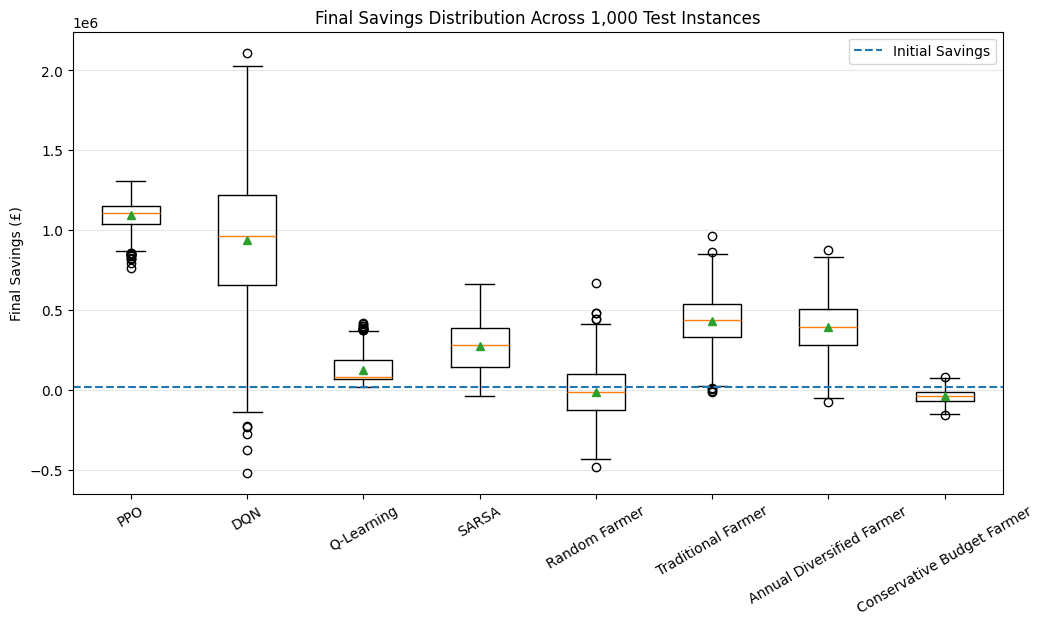

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 16

# STEP 1: Create a new figure for the boxplot
# The figure size is set to 12 inches wide and 6 inches tall for clear readability.
plt.figure(figsize=(12, 6))

# STEP 2: Prepare savings data for plotting
# all_savings contains final savings arrays for each evaluated algorithm.
# Each item in data_to_plot represents the 1,000 final savings values for one algorithm.
data_to_plot = [all_savings[name] for name in all_savings.keys()]

# STEP 3: Create a boxplot of final savings
# The boxplot shows the distribution of results for each algorithm.
# showmeans=True displays the mean value in addition to the median.
plt.boxplot(data_to_plot, tick_labels=list(all_savings.keys()), showmeans=True)

# STEP 4: Add a horizontal reference line for initial savings
# This helps compare whether each algorithm ends above or below the starting balance.
plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")

# STEP 5: Add a title to the graph
# This explains what the figure represents.
plt.title("Final Savings Distribution Across 1,000 Test Instances")

# STEP 6: Label the y-axis
# The y-axis shows the final financial balance in pounds.
plt.ylabel("Final Savings (£)")

# STEP 7: Rotate x-axis labels
# This prevents algorithm names from overlapping.
plt.xticks(rotation=30)

# STEP 8: Add a legend
# The legend identifies the initial savings reference line.
plt.legend()

# STEP 9: Add horizontal grid lines
# This improves readability when comparing savings values.
plt.grid(axis="y", alpha=0.3)

# STEP 10: Display the plot
# This renders the final savings distribution chart in the notebook.
plt.show()

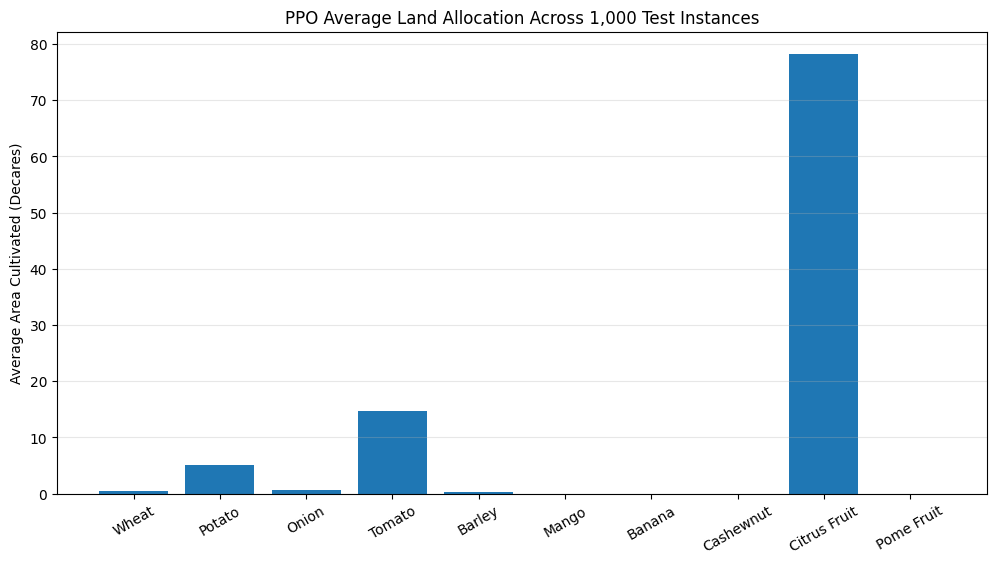

In [ ]:
# CELL 17

# STEP 1: Select crop allocation statistics for PPO
# all_crop_stats contains crop-area statistics for every evaluated algorithm.
# This line extracts only the PPO crop allocation table.
ppo_crop_stats = all_crop_stats["PPO"]

# STEP 2: Create a new figure for the bar chart
# The figure size is set to 12 inches wide and 6 inches tall for readability.
plt.figure(figsize=(12, 6))

# STEP 3: Plot average land allocation for each crop/tree
# The x-axis shows crop/tree names.
# The y-axis shows the average area cultivated across 1,000 test simulations.
plt.bar(ppo_crop_stats["Crop/Tree"], ppo_crop_stats["Average Area Cultivated"])

# STEP 4: Add a title to the graph
# This explains that the chart shows PPO's average crop allocation behaviour.
plt.title("PPO Average Land Allocation Across 1,000 Test Instances")

# STEP 5: Label the y-axis
# The y-axis shows average cultivated area measured in decares.
plt.ylabel("Average Area Cultivated (Decares)")

# STEP 6: Rotate x-axis labels
# This prevents crop names from overlapping and improves readability.
plt.xticks(rotation=30)

# STEP 7: Add horizontal grid lines
# This makes it easier to compare cultivated area values across crops.
plt.grid(axis="y", alpha=0.3)

# STEP 8: Display the chart
# This renders the PPO land allocation bar chart in the notebook.
plt.show()

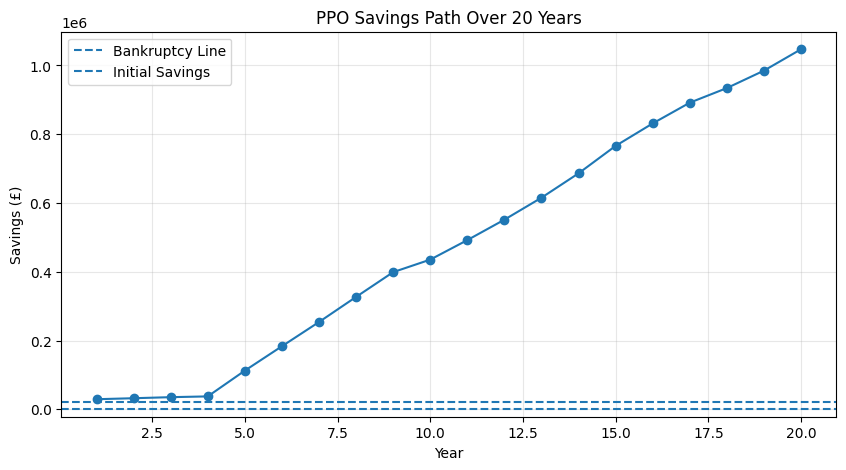

,Year,Savings,Cold Happened,Low Rain Happened
0,1,2.924753e+04,False,True
1,2,3.215323e+04,False,True
2,3,3.521066e+04,True,False
3,4,3.744705e+04,True,True
4,5,1.123816e+05,False,False
5,6,1.833173e+05,False,False
6,7,2.537875e+05,False,False
7,8,3.267601e+05,False,True
8,9,3.988694e+05,False,True
9,10,4.352591e+05,True,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 18
def plot_single_ppo_path(model, seed=123):
    env = FarmEnv()
    obs, _ = env.reset(seed=seed)

    years = []
    savings = []
    cold_events = []
    rain_events = []

    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        years.append(env.current_year)
        savings.append(info["savings"])
        cold_events.append(info["cold_happened"])
        rain_events.append(info["low_rain_happened"])

    plt.figure(figsize=(10, 5))
    plt.plot(years, savings, marker="o")
    plt.axhline(0, linestyle="--", label="Bankruptcy Line")
    plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
    plt.title("PPO Savings Path Over 20 Years")
    plt.xlabel("Year")
    plt.ylabel("Savings (£)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return pd.DataFrame({
        "Year": years,
        "Savings": savings,
        "Cold Happened": cold_events,
        "Low Rain Happened": rain_events
    })


ppo_path_df = plot_single_ppo_path(ppo_model)
display(ppo_path_df)

In [ ]:
# CELL 19
os.makedirs("outputs", exist_ok=True)

summary_df.to_csv("outputs/final_algorithm_statistics.csv", index=False)

for algorithm_name, crop_stats in all_crop_stats.items():
    filename = algorithm_name.replace(" ", "_").replace("-", "_").lower()
    crop_stats.to_csv(f"outputs/{filename}_crop_area_statistics.csv", index=False)

print("Saved output files in /outputs/")

Saved output files in /outputs/


In [ ]:
# CELL 20 
# Convert final savings dictionary into long-format dataframe

results_long = []

for algo, savings_array in all_savings.items():
    for value in savings_array:
        results_long.append({
            "Algorithm": algo,
            "Final Savings": value
        })

results_long_df = pd.DataFrame(results_long)

display(results_long_df.head())

,Algorithm,Final Savings
0,PPO,1.085208e+06
1,PPO,1.169492e+06
2,PPO,1.034078e+06
3,PPO,1.143753e+06
4,PPO,9.948973e+05


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 21
advanced_summary_df = summary_df.copy()

# Add percentile information from raw final-savings arrays.
for percentile in [25, 75]:
    advanced_summary_df[f"{percentile}th Percentile (£)"] = advanced_summary_df["Algorithm"].map(
        lambda algo: np.percentile(all_savings[algo], percentile)
    )

# Report-ready ordering and column names.
report_table_df = advanced_summary_df[[
    "Algorithm",
    "Mean Final Savings (£)",
    "Std Dev (£)",
    "Minimum Final Savings (£)",
    "Maximum Final Savings (£)",
    "Mean Minimum Savings During Run (£)",
    "Ever-Bankruptcy Rate (%)",
    "Final Bankruptcy Rate (%)",
    "Success Rate (%)",
    "Risk-Adjusted Score",
    "Average Cold Events",
    "Average Low Rain Events"
]].copy()

# Rounded version for dissertation tables.
report_table_rounded = report_table_df.copy()
for col in report_table_rounded.columns:
    if col != "Algorithm":
        report_table_rounded[col] = report_table_rounded[col].round(2)

print("Report-ready model performance table")
display(report_table_rounded)

report_table_df.to_csv("outputs/report_ready_model_performance_table.csv", index=False)
report_table_rounded.to_csv("outputs/report_ready_model_performance_table_rounded.csv", index=False)


Report-ready model performance table


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,Mean Final Savings (£),Std Dev (£),Minimum Final Savings (£),Maximum Final Savings (£),Mean Minimum Savings During Run (£),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),Success Rate (%),Risk-Adjusted Score,Average Cold Events,Average Low Rain Events
0,PPO,1094106.46,87320.05,763330.44,1307057.75,-86551.57,100.0,0.0,100.0,12.53,8.07,8.01
1,DQN,939246.71,407033.94,-516157.00,2110587.50,-175236.23,100.0,1.3,98.5,2.31,8.00,7.91
2,Q-Learning,128335.08,88862.61,22733.20,418706.69,-9843.01,99.7,0.0,100.0,1.44,8.04,7.95
3,SARSA,275108.46,148457.32,-36331.24,662262.50,-111853.08,100.0,0.2,98.6,1.85,7.86,7.97
4,Random Farmer,-9033.05,160306.76,-481855.81,669124.88,-203372.40,100.0,53.1,42.4,-0.06,8.04,8.06
5,Traditional Farmer,434802.38,158748.50,-12955.48,963850.31,-127306.12,100.0,0.2,99.6,2.74,8.04,7.93
6,Annual Diversified Farmer,392981.15,164958.50,-71757.21,879105.88,-74332.73,100.0,0.9,98.7,2.38,8.01,7.95
7,Conservative Budget Farmer,-36614.02,41435.00,-153290.52,85019.62,-71019.80,100.0,81.0,8.6,-0.88,8.01,7.95


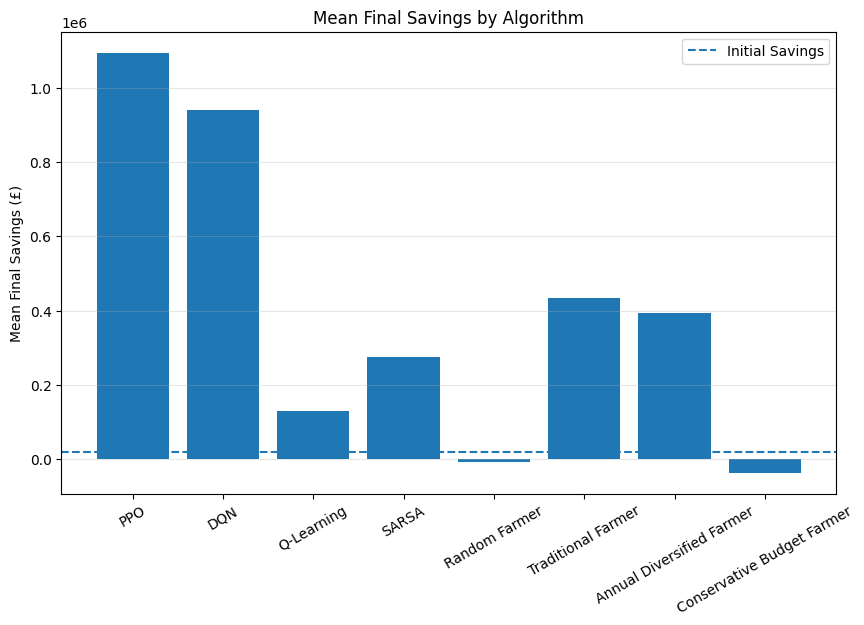

In [ ]:
# CELL 22
plt.figure(figsize=(10, 6))

plt.bar(
    advanced_summary_df["Algorithm"],
    advanced_summary_df["Mean Final Savings (£)"]
)

plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
plt.title("Mean Final Savings by Algorithm")
plt.ylabel("Mean Final Savings (£)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

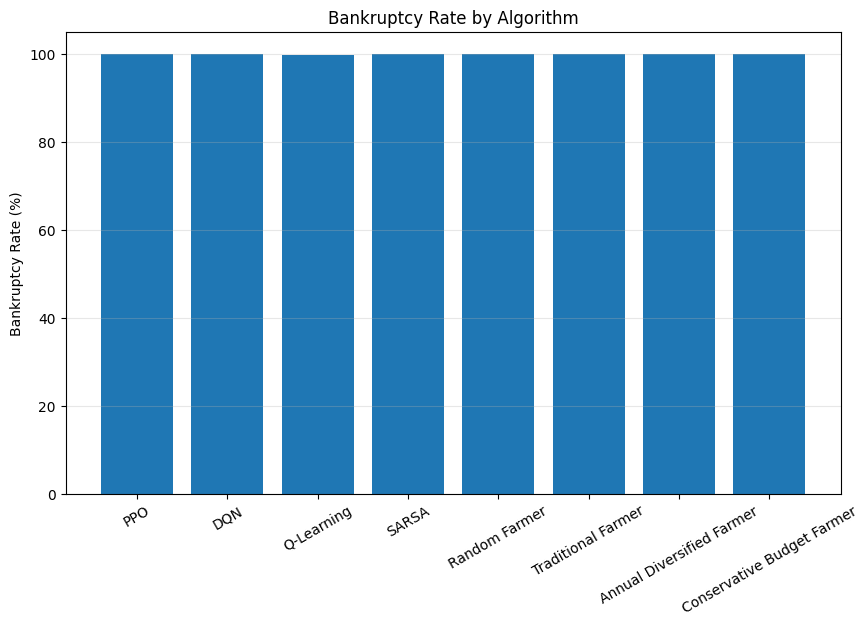

In [ ]:
# CELL 23
plt.figure(figsize=(10, 6))

plt.bar(
    advanced_summary_df["Algorithm"],
    advanced_summary_df["Ever-Bankruptcy Rate (%)"]
)

plt.title("Bankruptcy Rate by Algorithm")
plt.ylabel("Bankruptcy Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

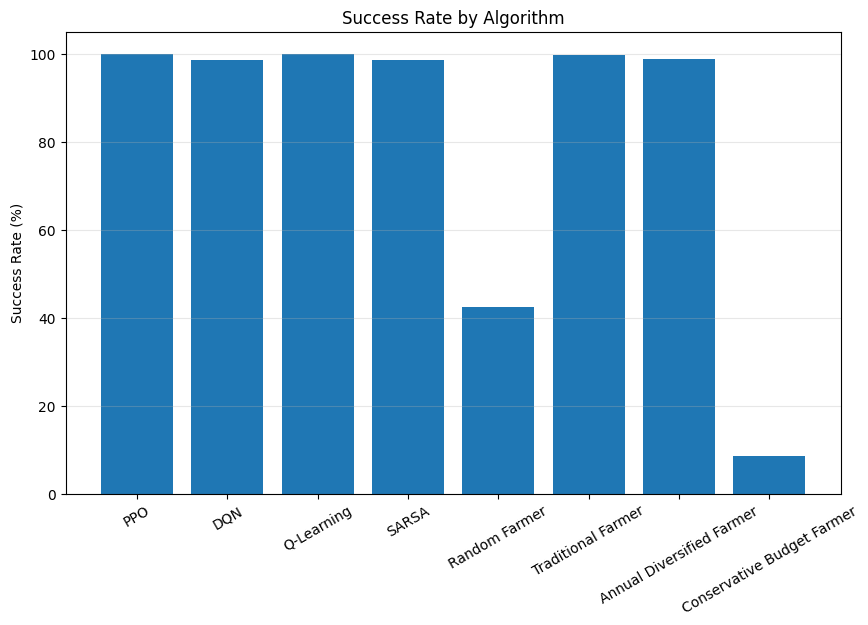

In [ ]:
# CELL 24
plt.figure(figsize=(10, 6))

plt.bar(
    advanced_summary_df["Algorithm"],
    advanced_summary_df["Success Rate (%)"]
)

plt.title("Success Rate by Algorithm")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

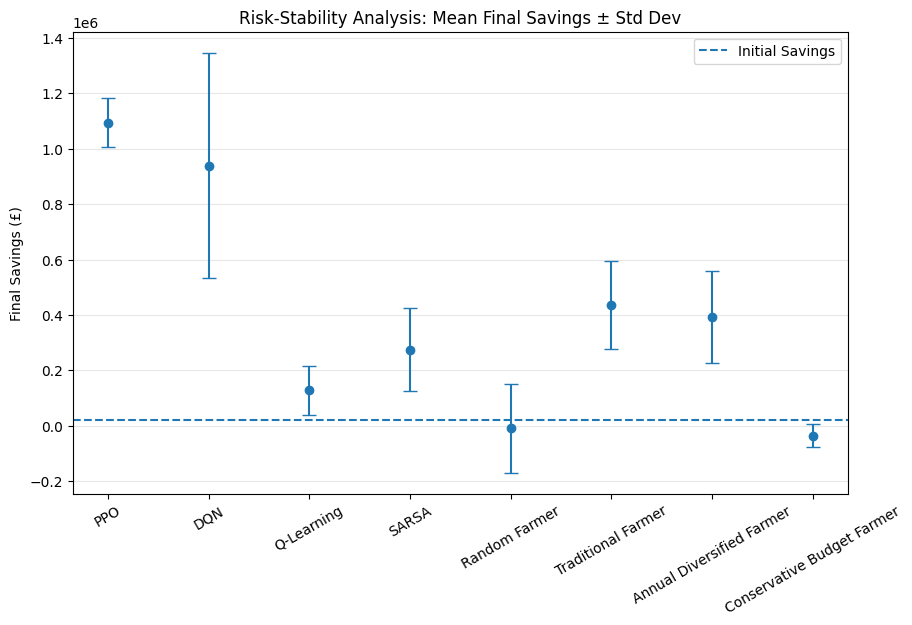

In [ ]:
# CELL 25
plt.figure(figsize=(10, 6))

plt.errorbar(
    advanced_summary_df["Algorithm"],
    advanced_summary_df["Mean Final Savings (£)"],
    yerr=advanced_summary_df["Std Dev (£)"],
    fmt="o",
    capsize=5
)

plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
plt.title("Risk-Stability Analysis: Mean Final Savings ± Std Dev")
plt.ylabel("Final Savings (£)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

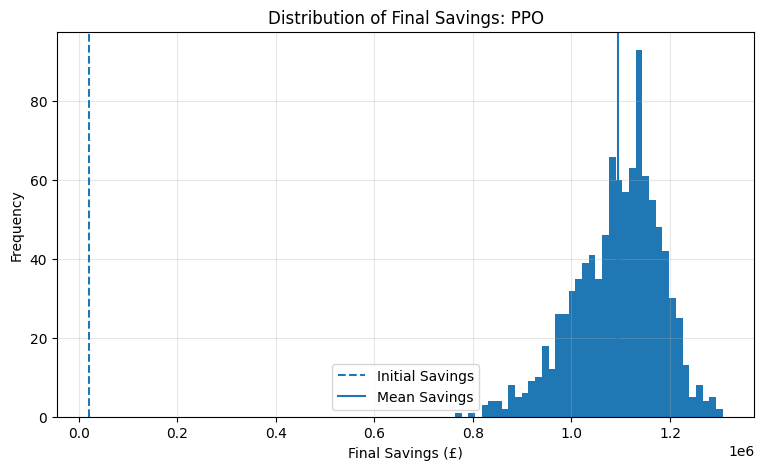

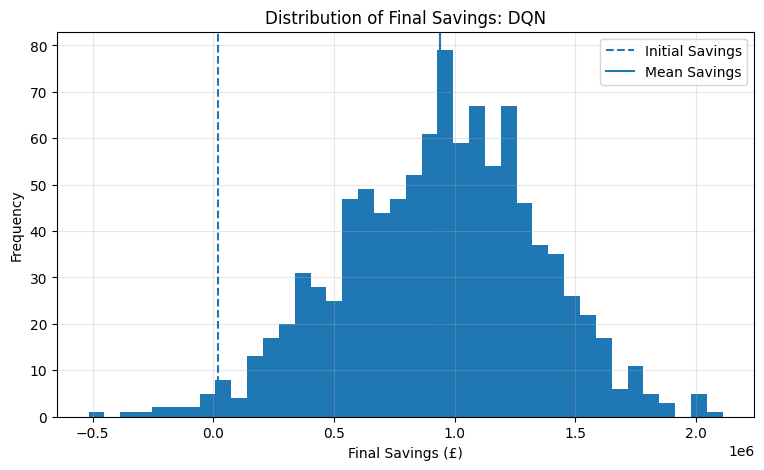

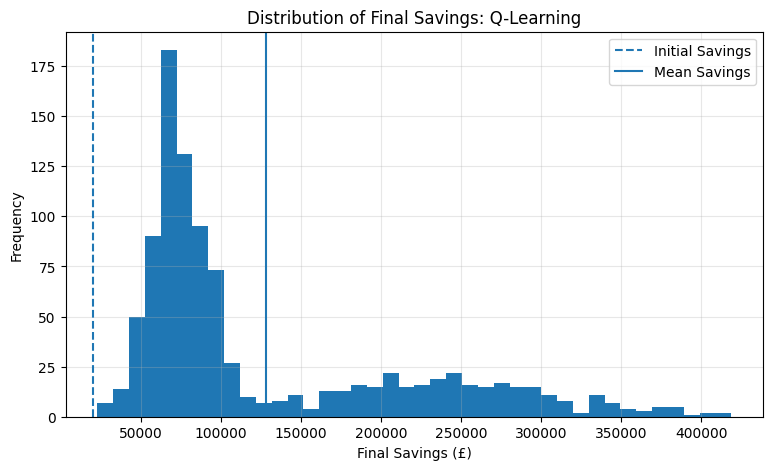

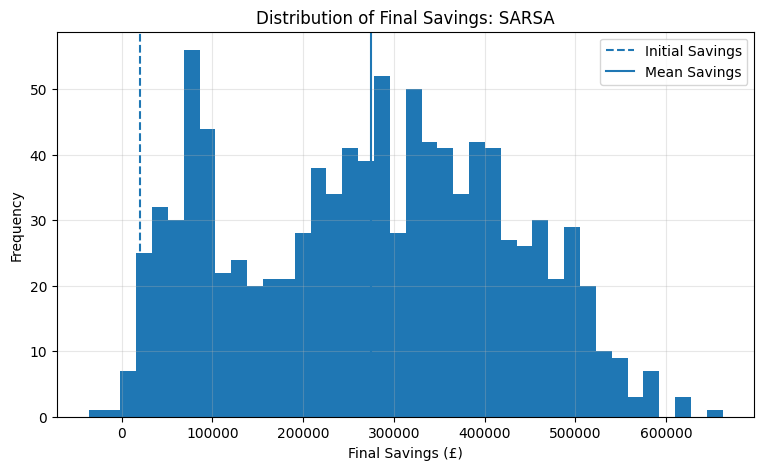

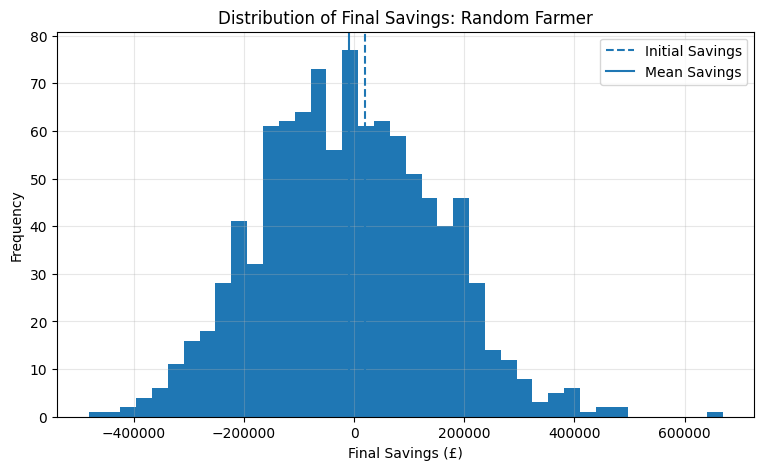

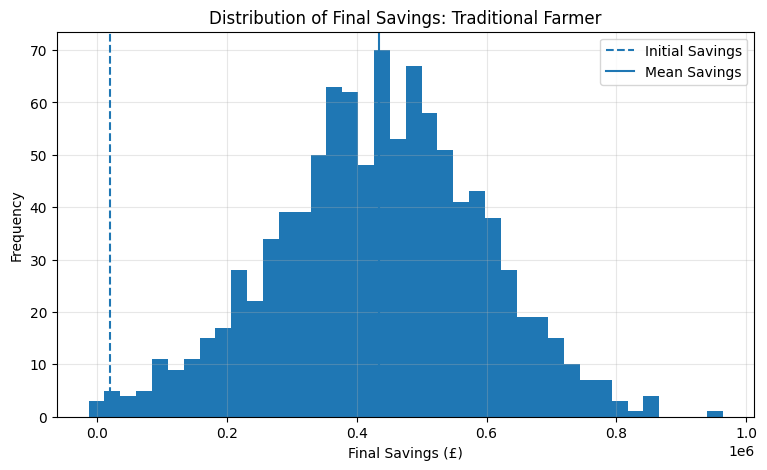

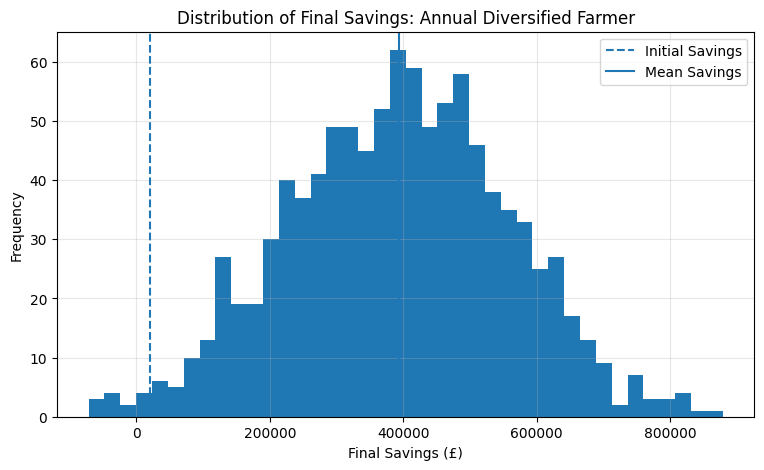

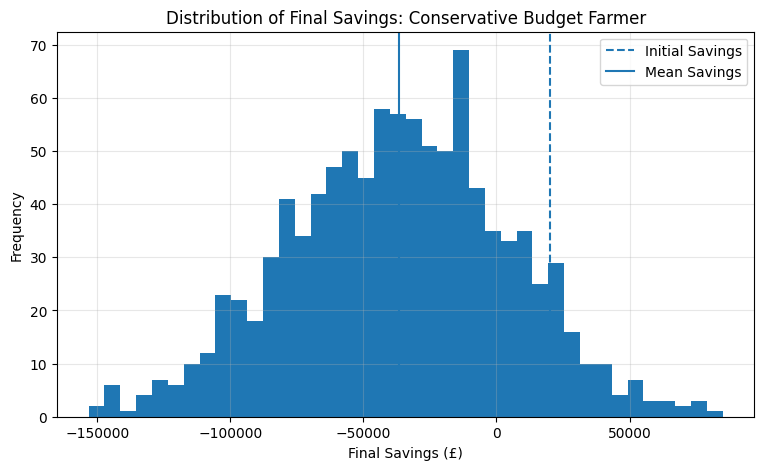

In [ ]:
# CELL26
for algo, savings_array in all_savings.items():
    plt.figure(figsize=(9, 5))
    plt.hist(savings_array, bins=40)
    plt.axvline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
    plt.axvline(np.mean(savings_array), linestyle="-", label="Mean Savings")

    plt.title(f"Distribution of Final Savings: {algo}")
    plt.xlabel("Final Savings (£)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# CELL 27
allocation_matrix = []

for algo, crop_stats in all_crop_stats.items():
    row = {"Algorithm": algo}

    for _, r in crop_stats.iterrows():
        row[r["Crop/Tree"]] = r["Average Area Cultivated"]

    allocation_matrix.append(row)

allocation_df = pd.DataFrame(allocation_matrix)
display(allocation_df)

allocation_df.to_csv("outputs/algorithm_crop_allocation_matrix.csv", index=False)

,Algorithm,Wheat,Potato,Onion,Tomato,Barley,Mango,Banana,Cashewnut,Citrus Fruit,Pome Fruit
0,PPO,0.467700,5.142202,0.676028,14.677333,0.348289,0.000000,0.000000,0.000000,78.273175,0.000000
1,DQN,0.000000,0.730000,0.000000,99.270000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Q-Learning,67.683000,3.898000,2.023000,2.023000,22.203000,0.000000,0.000000,0.000000,0.000000,0.000000
3,SARSA,31.243000,16.213500,6.438000,14.103000,18.243000,0.005000,0.005000,4.155000,0.125000,0.005000
4,Random Farmer,9.467828,9.392516,9.426622,9.316128,9.475334,9.347962,9.364457,9.370384,9.385750,9.434793
5,Traditional Farmer,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
6,Annual Diversified Farmer,20.000000,20.000000,20.000000,20.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Conservative Budget Farmer,5.000000,5.000000,5.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


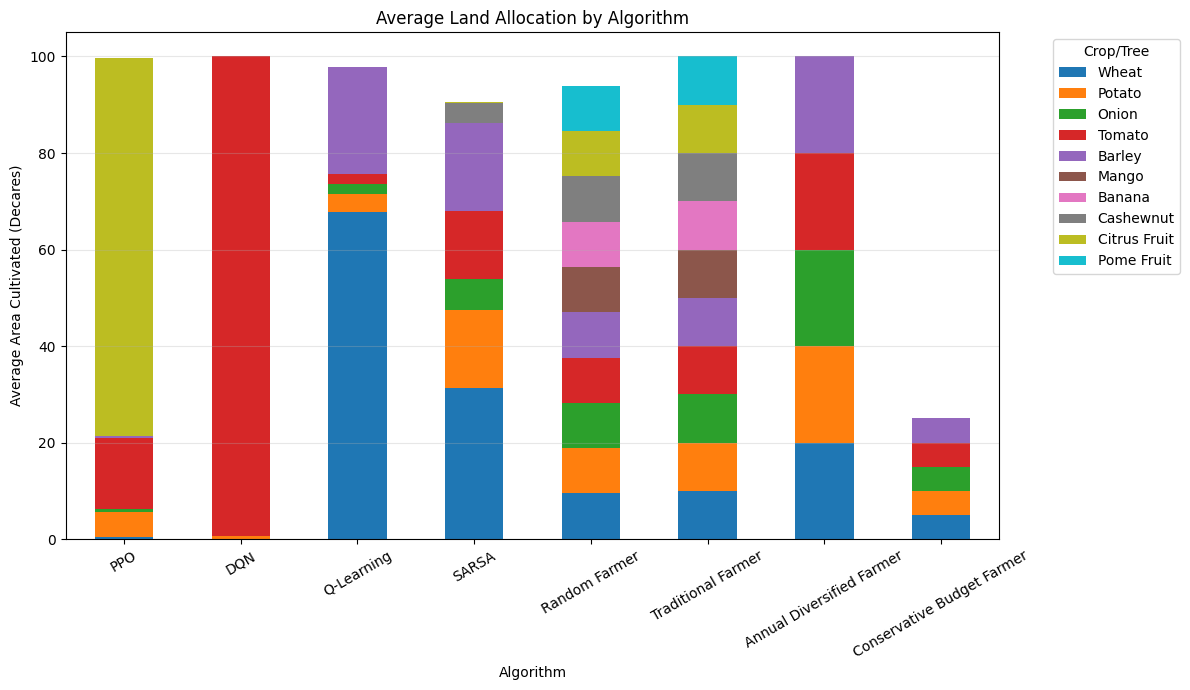

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 28
allocation_plot_df = allocation_df.set_index("Algorithm")

allocation_plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Average Land Allocation by Algorithm")
plt.ylabel("Average Area Cultivated (Decares)")
plt.xticks(rotation=30)
plt.legend(title="Crop/Tree", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

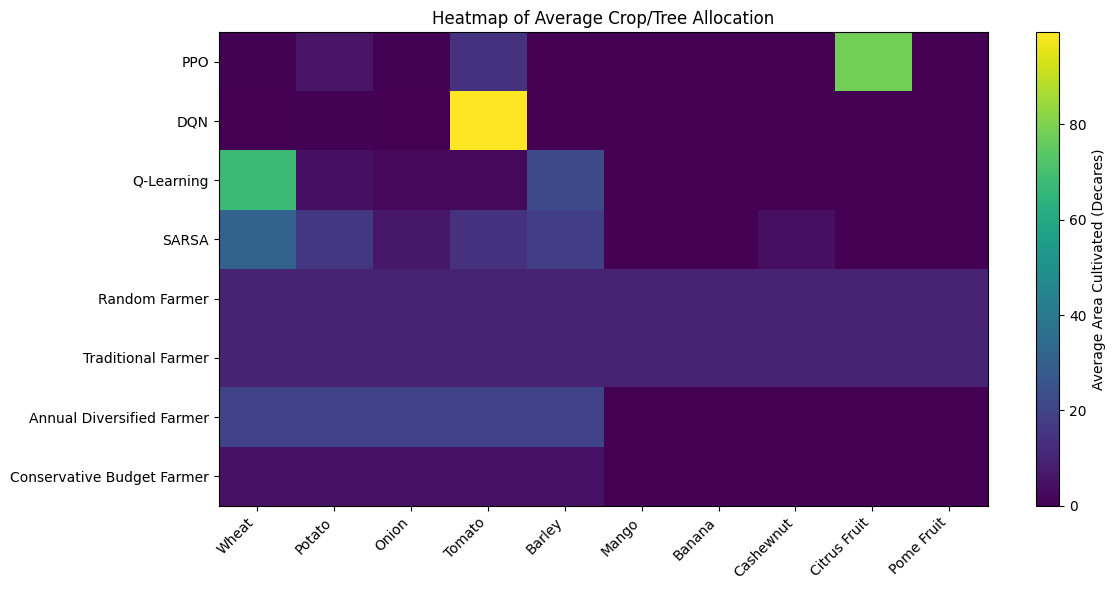

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 29
heatmap_data = allocation_plot_df.values

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")

plt.xticks(
    ticks=np.arange(len(allocation_plot_df.columns)),
    labels=allocation_plot_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(allocation_plot_df.index)),
    labels=allocation_plot_df.index
)

plt.colorbar(label="Average Area Cultivated (Decares)")
plt.title("Heatmap of Average Crop/Tree Allocation")
plt.tight_layout()
plt.show()

In [ ]:
# CELL 30 
 weather_stats = []

for algo in all_stats:
    weather_stats.append({
        "Algorithm": algo["Algorithm"],
        "Average Cold Events": algo["Average Cold Events"],
        "Average Low Rain Events": algo["Average Low Rain Events"]
    })

weather_df = pd.DataFrame(weather_stats)
display(weather_df)

weather_df.to_csv("outputs/weather_event_statistics.csv", index=False)

,Algorithm,Average Cold Events,Average Low Rain Events
0,PPO,8.069,8.009
1,DQN,8.002,7.910
2,Q-Learning,8.043,7.950
3,SARSA,7.858,7.974
4,Random Farmer,8.040,8.060
5,Traditional Farmer,8.040,7.932
6,Annual Diversified Farmer,8.014,7.951
7,Conservative Budget Farmer,8.014,7.951


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


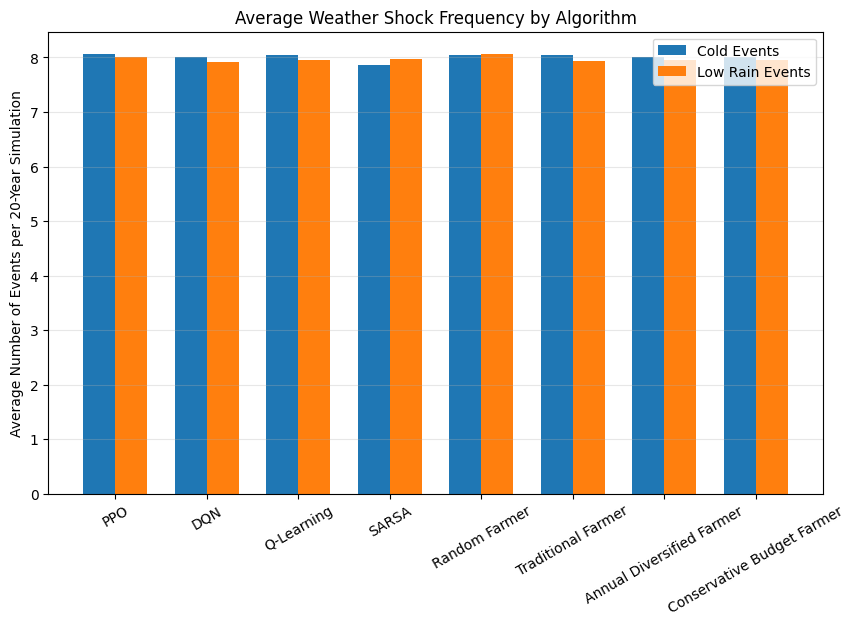

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 31
x = np.arange(len(weather_df["Algorithm"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    weather_df["Average Cold Events"],
    width,
    label="Cold Events"
)

plt.bar(
    x + width / 2,
    weather_df["Average Low Rain Events"],
    width,
    label="Low Rain Events"
)

plt.xticks(x, weather_df["Algorithm"], rotation=30)
plt.ylabel("Average Number of Events per 20-Year Simulation")
plt.title("Average Weather Shock Frequency by Algorithm")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

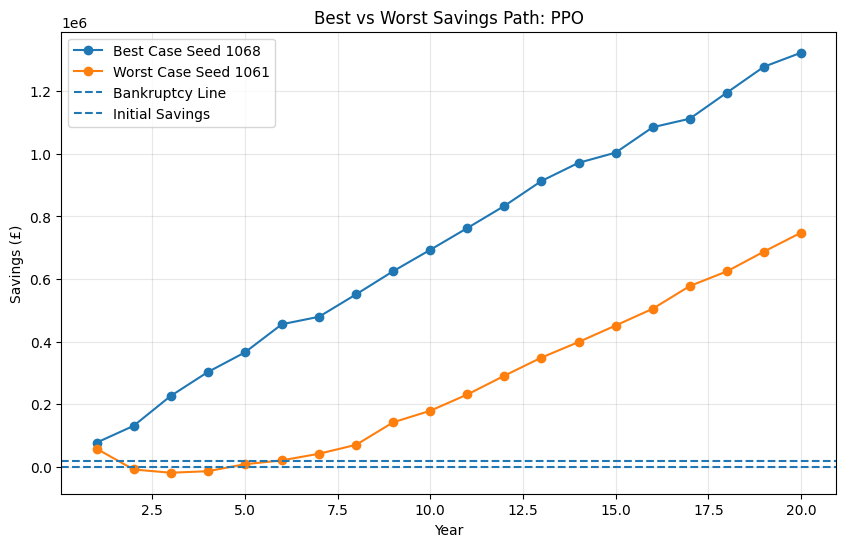

In [ ]:
# CELL 32
def run_policy_path(algorithm_name, model=None, tabular_agent=None, policy=None, seed=123):
    env = FarmEnv()
    obs, _ = env.reset(seed=seed)

    years = []
    savings = []
    cold_events = []
    rain_events = []
    allocations = []

    done = False

    while not done:
        if algorithm_name == "PPO":
            action, _ = model.predict(obs, deterministic=True)

        elif algorithm_name == "DQN":
            action_index, _ = model.predict(obs, deterministic=True)
            action = discrete_action_to_continuous(int(action_index))

        elif algorithm_name in ["Q-Learning", "SARSA"]:
            state = tabular_agent.discretize_state(obs)
            action_index = tabular_agent.choose_action(state, explore=False)
            action = discrete_action_to_continuous(action_index)

        elif policy is not None:
            action = policy(obs)

        else:
            raise ValueError("Invalid policy setup.")

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        years.append(env.current_year)
        savings.append(info["savings"])
        cold_events.append(info["cold_happened"])
        rain_events.append(info["low_rain_happened"])
        allocations.append(info["areas"])

    return pd.DataFrame({
        "Year": years,
        "Savings": savings,
        "Cold Happened": cold_events,
        "Low Rain Happened": rain_events
    }), np.array(allocations)


def compare_best_worst_paths(algorithm_name, model=None, tabular_agent=None, policy=None):
    seed_results = []

    for seed in range(1000, 1100):
        path_df, _ = run_policy_path(
            algorithm_name,
            model=model,
            tabular_agent=tabular_agent,
            policy=policy,
            seed=seed
        )

        seed_results.append({
            "Seed": seed,
            "Final Savings": path_df["Savings"].iloc[-1]
        })

    seed_results_df = pd.DataFrame(seed_results)

    best_seed = int(seed_results_df.sort_values("Final Savings", ascending=False).iloc[0]["Seed"])
    worst_seed = int(seed_results_df.sort_values("Final Savings", ascending=True).iloc[0]["Seed"])

    best_path, _ = run_policy_path(
        algorithm_name,
        model=model,
        tabular_agent=tabular_agent,
        policy=policy,
        seed=best_seed
    )

    worst_path, _ = run_policy_path(
        algorithm_name,
        model=model,
        tabular_agent=tabular_agent,
        policy=policy,
        seed=worst_seed
    )

    plt.figure(figsize=(10, 6))
    plt.plot(best_path["Year"], best_path["Savings"], marker="o", label=f"Best Case Seed {best_seed}")
    plt.plot(worst_path["Year"], worst_path["Savings"], marker="o", label=f"Worst Case Seed {worst_seed}")

    plt.axhline(0, linestyle="--", label="Bankruptcy Line")
    plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")

    plt.title(f"Best vs Worst Savings Path: {algorithm_name}")
    plt.xlabel("Year")
    plt.ylabel("Savings (£)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return best_path, worst_path


best_ppo_path, worst_ppo_path = compare_best_worst_paths(
    "PPO",
    model=ppo_model
)

,Mean Final Savings (£),Std Dev (£),Minimum Final Savings (£),Maximum Final Savings (£),Success Rate (%),Ever-Bankruptcy Rate (%),Risk-Adjusted Score
Mean Final Savings (£),1.000000,0.480103,0.448035,0.862531,0.612075,0.265104,0.807133
Std Dev (£),0.480103,1.000000,-0.551820,0.847145,0.366726,0.249597,-0.090007
Minimum Final Savings (£),0.448035,-0.551820,1.000000,-0.050832,0.343137,-0.085821,0.848455
Maximum Final Savings (£),0.862531,0.847145,-0.050832,1.000000,0.555353,0.308089,0.445091
Success Rate (%),0.612075,0.366726,0.343137,0.555353,1.000000,-0.219697,0.491642
Ever-Bankruptcy Rate (%),0.265104,0.249597,-0.085821,0.308089,-0.219697,1.000000,0.131533
Risk-Adjusted Score,0.807133,-0.090007,0.848455,0.445091,0.491642,0.131533,1.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


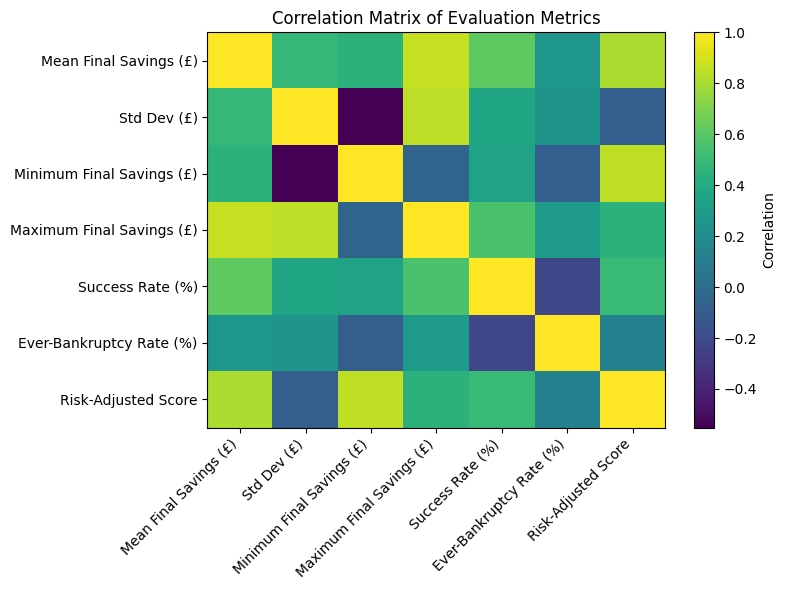

In [ ]:
# CELL 33
correlation_df = advanced_summary_df[
    [
        "Mean Final Savings (£)",
        "Std Dev (£)",
        "Minimum Final Savings (£)",
        "Maximum Final Savings (£)",
        "Success Rate (%)",
        "Ever-Bankruptcy Rate (%)",
        "Risk-Adjusted Score"
    ]
].corr()

display(correlation_df)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_df.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(correlation_df.columns)),
    labels=correlation_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(correlation_df.index)),
    labels=correlation_df.index
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix of Evaluation Metrics")
plt.tight_layout()
plt.show()

In [ ]:
# CELL 34
ranking_df = advanced_summary_df.copy()

ranking_df["Rank by Mean Savings"] = ranking_df["Mean Final Savings (£)"].rank(ascending=False)
ranking_df["Rank by Risk"] = ranking_df["Std Dev (£)"].rank(ascending=True)
ranking_df["Rank by Bankruptcy"] = ranking_df["Ever-Bankruptcy Rate (%)"].rank(ascending=True)
ranking_df["Rank by Risk-Adjusted Score"] = ranking_df["Risk-Adjusted Score"].rank(ascending=False)

ranking_df = ranking_df.sort_values("Rank by Risk-Adjusted Score")

display(ranking_df)

ranking_df.to_csv("outputs/algorithm_ranking_table.csv", index=False)

,Algorithm,Mean Final Savings (£),Median Final Savings (£),Std Dev (£),Minimum Final Savings (£),Maximum Final Savings (£),Mean Minimum Savings During Run (£),Success Rate (%),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),Average Cold Events,Average Low Rain Events,Risk-Adjusted Score,25th Percentile (£),75th Percentile (£),Rank by Mean Savings,Rank by Risk,Rank by Bankruptcy,Rank by Risk-Adjusted Score
0,PPO,1.094106e+06,1.106196e+06,87320.047984,763330.437500,1.307058e+06,-86551.571086,100.0,100.0,0.0,8.069,8.009,12.529843,1.038455e+06,1.153682e+06,1.0,2.0,5.0,1.0
5,Traditional Farmer,4.348024e+05,4.411642e+05,158748.498114,-12955.484375,9.638503e+05,-127306.120398,99.6,100.0,0.2,8.040,7.932,2.738939,3.341512e+05,5.413030e+05,3.0,5.0,5.0,2.0
6,Annual Diversified Farmer,3.929812e+05,3.964356e+05,164958.504506,-71757.210938,8.791059e+05,-74332.729043,98.7,100.0,0.9,8.014,7.951,2.382303,2.803207e+05,5.054161e+05,4.0,7.0,5.0,3.0
1,DQN,9.392467e+05,9.611986e+05,407033.944732,-516157.000000,2.110588e+06,-175236.229305,98.5,100.0,1.3,8.002,7.910,2.307539,6.558855e+05,1.221785e+06,2.0,8.0,5.0,4.0
3,SARSA,2.751085e+05,2.838073e+05,148457.320420,-36331.242188,6.622625e+05,-111853.078531,98.6,100.0,0.2,7.858,7.974,1.853115,1.458915e+05,3.910546e+05,5.0,4.0,5.0,5.0
2,Q-Learning,1.283351e+05,8.510842e+04,88862.613172,22733.195312,4.187067e+05,-9843.008955,100.0,99.7,0.0,8.043,7.950,1.444197,6.778570e+04,1.896560e+05,6.0,3.0,1.0,6.0
4,Random Farmer,-9.033048e+03,-1.178300e+04,160306.764047,-481855.812500,6.691249e+05,-203372.401160,42.4,100.0,53.1,8.040,8.060,-0.056349,-1.250127e+05,1.018888e+05,7.0,6.0,5.0,7.0
7,Conservative Budget Farmer,-3.661402e+04,-3.570971e+04,41435.001757,-153290.515625,8.501962e+04,-71019.803393,8.6,100.0,81.0,8.014,7.951,-0.883650,-6.539186e+04,-8.599163e+03,8.0,1.0,5.0,8.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


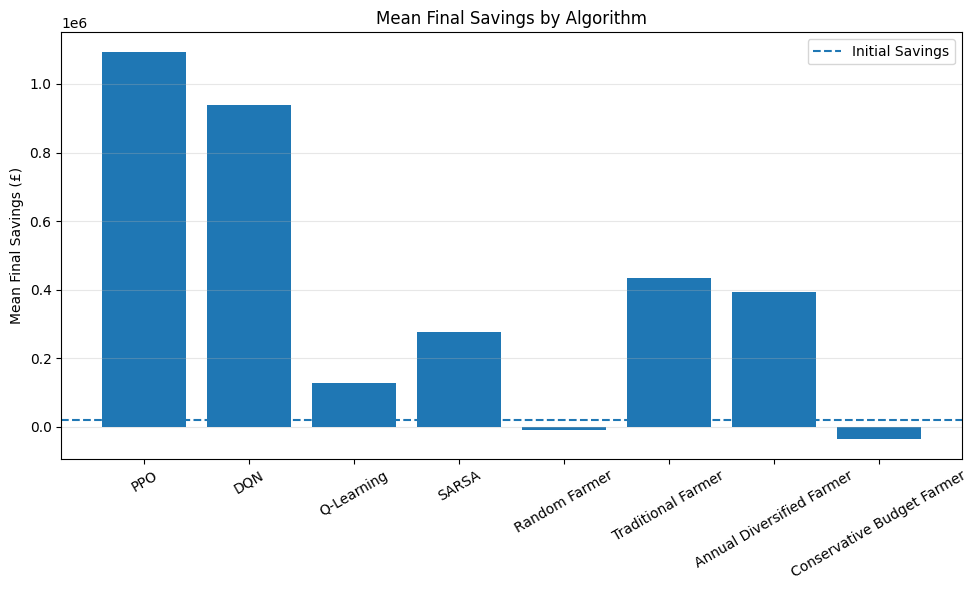

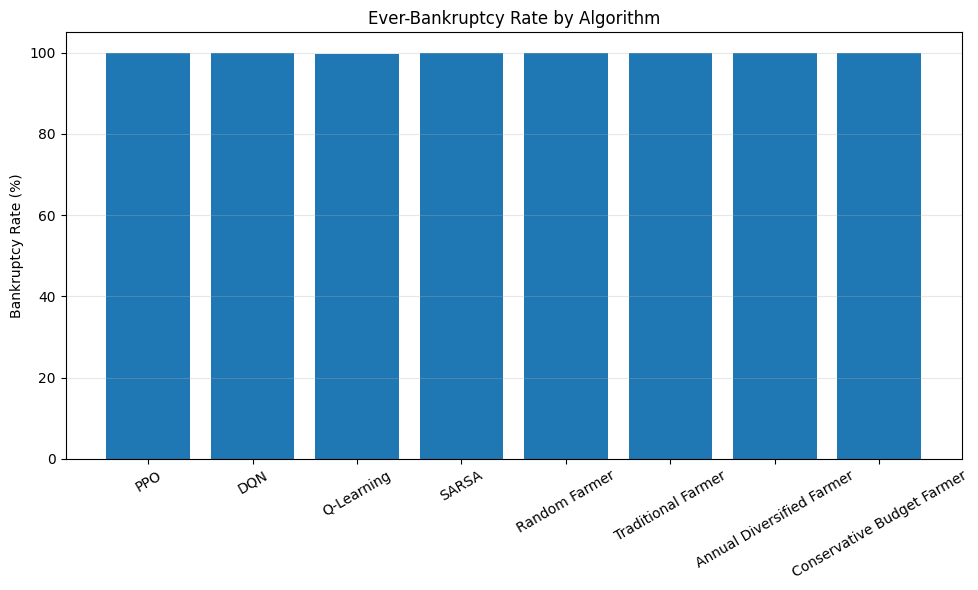

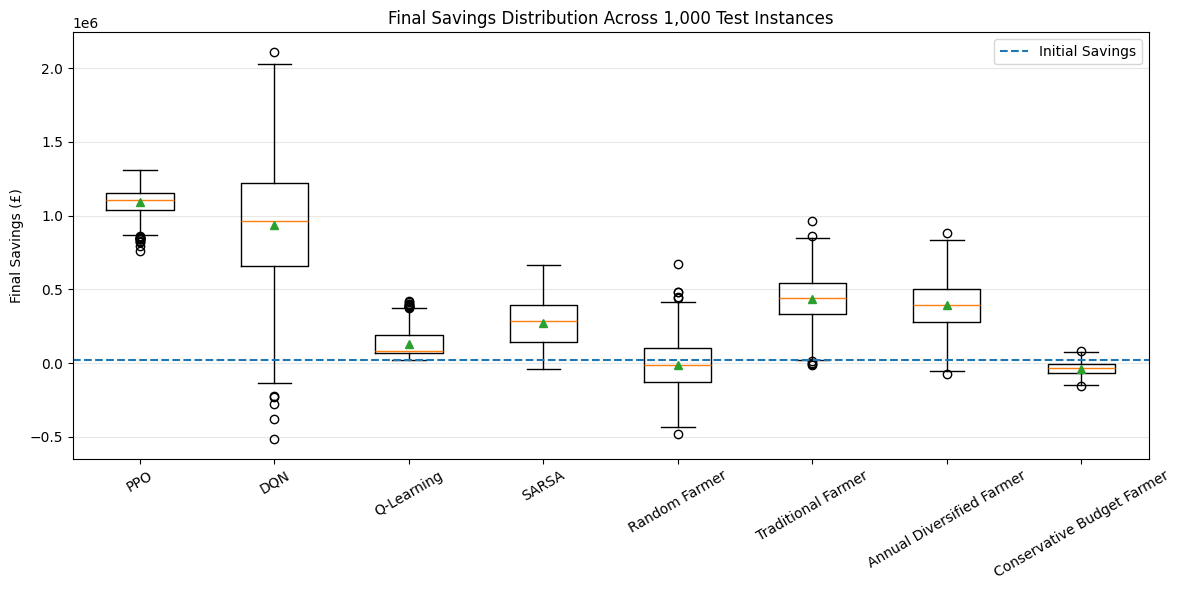

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


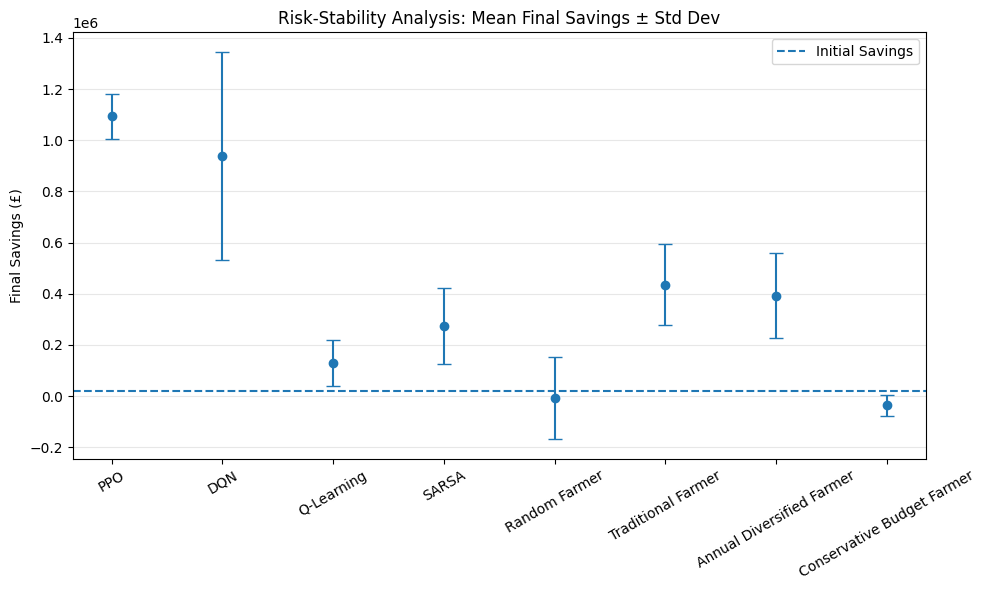

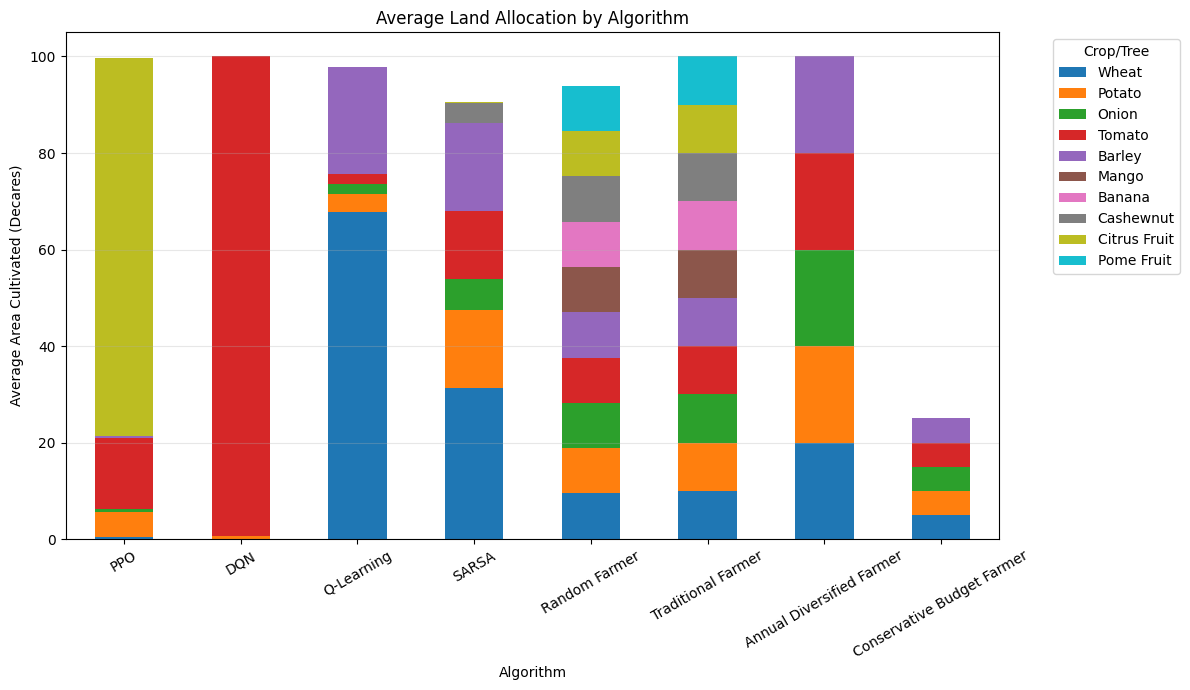

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


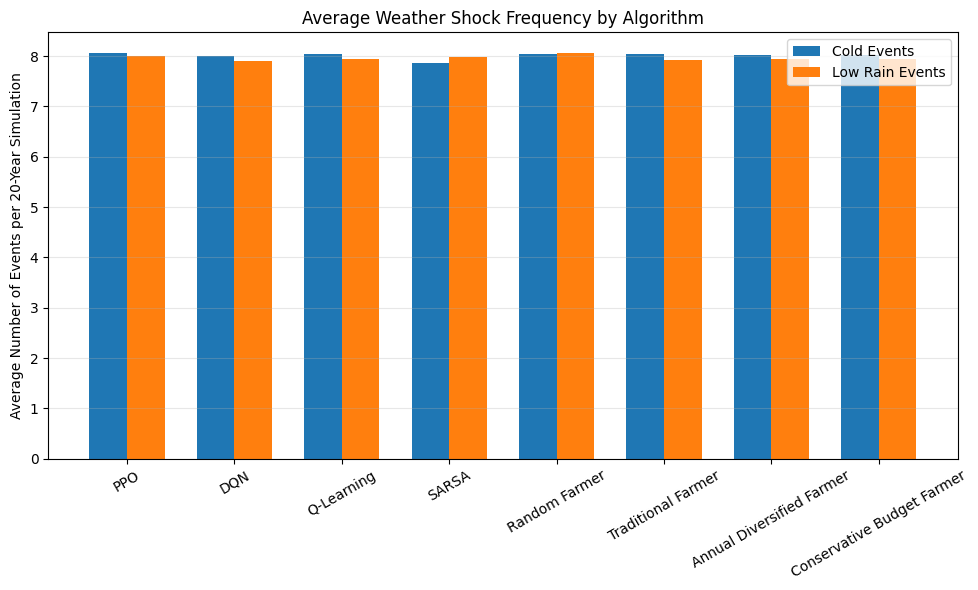

In [ ]:
# CELL 35
os.makedirs("outputs/figures", exist_ok=True)

# 1. Mean final savings by algorithm
plt.figure(figsize=(10, 6))
plt.bar(report_table_df["Algorithm"], report_table_df["Mean Final Savings (£)"])
plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
plt.title("Mean Final Savings by Algorithm")
plt.ylabel("Mean Final Savings (£)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/01_mean_final_savings.png", dpi=300)
plt.show()

# 2. Ever-bankruptcy rate by algorithm
plt.figure(figsize=(10, 6))
plt.bar(report_table_df["Algorithm"], report_table_df["Ever-Bankruptcy Rate (%)"])
plt.title("Ever-Bankruptcy Rate by Algorithm")
plt.ylabel("Bankruptcy Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/02_ever_bankruptcy_rate.png", dpi=300)
plt.show()

# 3. Distribution of final savings
plt.figure(figsize=(12, 6))
data_to_plot = [all_savings[name] for name in report_table_df["Algorithm"]]
plt.boxplot(data_to_plot, tick_labels=list(report_table_df["Algorithm"]), showmeans=True)
plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
plt.title("Final Savings Distribution Across 1,000 Test Instances")
plt.ylabel("Final Savings (£)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/03_final_savings_distribution.png", dpi=300)
plt.show()

# 4. Risk-stability plot
plt.figure(figsize=(10, 6))
plt.errorbar(
    report_table_df["Algorithm"],
    report_table_df["Mean Final Savings (£)"],
    yerr=report_table_df["Std Dev (£)"],
    fmt="o",
    capsize=5
)
plt.axhline(INITIAL_SAVINGS, linestyle="--", label="Initial Savings")
plt.title("Risk-Stability Analysis: Mean Final Savings ± Std Dev")
plt.ylabel("Final Savings (£)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/04_risk_stability_mean_std.png", dpi=300)
plt.show()

# 5. Average land allocation by algorithm
allocation_plot_df = allocation_df.set_index("Algorithm")
allocation_plot_df.plot(kind="bar", stacked=True, figsize=(12, 7))
plt.title("Average Land Allocation by Algorithm")
plt.ylabel("Average Area Cultivated (Decares)")
plt.xticks(rotation=30)
plt.legend(title="Crop/Tree", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/05_average_land_allocation_by_algorithm.png", dpi=300)
plt.show()

# 6. Weather shock frequency
x = np.arange(len(weather_df["Algorithm"]))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, weather_df["Average Cold Events"], width, label="Cold Events")
plt.bar(x + width / 2, weather_df["Average Low Rain Events"], width, label="Low Rain Events")
plt.xticks(x, weather_df["Algorithm"], rotation=30)
plt.ylabel("Average Number of Events per 20-Year Simulation")
plt.title("Average Weather Shock Frequency by Algorithm")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/06_weather_shock_frequency.png", dpi=300)
plt.show()


In [ ]:
# CELL 36
best_mean_algo = advanced_summary_df.sort_values("Mean Final Savings (£)", ascending=False).iloc[0]
best_risk_algo = advanced_summary_df.sort_values("Std Dev (£)", ascending=True).iloc[0]
lowest_bankruptcy_algo = advanced_summary_df.sort_values("Ever-Bankruptcy Rate (%)", ascending=True).iloc[0]
best_risk_adjusted_algo = advanced_summary_df.sort_values("Risk-Adjusted Score", ascending=False).iloc[0]

print("Dissertation Interpretation Summary")
print("----------------------------------")
print(f"Highest average savings: {best_mean_algo['Algorithm']} (£{best_mean_algo['Mean Final Savings (£)']:,.2f})")
print(f"Most stable algorithm: {best_risk_algo['Algorithm']} (Std Dev £{best_risk_algo['Std Dev (£)']:,.2f})")
print(f"Lowest bankruptcy rate: {lowest_bankruptcy_algo['Algorithm']} ({lowest_bankruptcy_algo['Ever-Bankruptcy Rate (%)']:.2f}%)")
print(f"Best risk-adjusted score: {best_risk_adjusted_algo['Algorithm']} ({best_risk_adjusted_algo['Risk-Adjusted Score']:.4f})")

Dissertation Interpretation Summary
----------------------------------
Highest average savings: PPO (£1,094,106.46)
Most stable algorithm: Conservative Budget Farmer (Std Dev £41,435.00)
Lowest bankruptcy rate: Q-Learning (99.70%)
Best risk-adjusted score: PPO (12.5298)
